In [1]:
# ── CREDIT RISK MODEL — LENDING CLUB ──────────────────────────────────────────
# Part 1: Setup, Load Data, First Look
# Run this on Google Colab
# Dataset: https://www.kaggle.com/datasets/wordsforthewise/lending-club
# Download and upload the CSV to Colab (or mount Google Drive)
# ──────────────────────────────────────────────────────────────────────────────

# install one thing kaggle doesn't have by default
!pip install openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────
# if you uploaded the file directly to colab session storage:
# df = pd.read_csv('accepted_2007_to_2018Q4.csv', low_memory=False)

# if you mounted google drive:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/lending_club/accepted_2007_to_2018Q4.csv',
                 low_memory=False)

print(f"Shape: {df.shape}")       # rows x columns
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (2260701, 151)
Memory: 6283.4 MB


In [2]:
# ── 2. FIRST LOOK ─────────────────────────────────────────────────────────────

# what does it look like
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0000,3600.0000,3600.0000,36 months,13.9900,123.0300,C,C4,leadman,10+ years,MORTGAGE,55000.0000,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.9100,0.0000,Aug-2003,675.0000,679.0000,1.0000,30.0000,NaN,7.0000,0.0000,2765.0000,29.7000,13.0000,w,0.0000,0.0000,...,178050.0000,7746.0000,2400.0000,13734.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0000,24700.0000,24700.0000,36 months,11.9900,820.2800,C,C1,Engineer,10+ years,MORTGAGE,65000.0000,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.0600,1.0000,Dec-1999,715.0000,719.0000,4.0000,6.0000,NaN,22.0000,0.0000,21470.0000,19.2000,38.0000,w,0.0000,0.0000,...,314017.0000,39475.0000,79300.0000,24667.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0000,20000.0000,20000.0000,60 months,10.7800,432.6600,B,B4,truck driver,10+ years,MORTGAGE,63000.0000,Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.7800,0.0000,Aug-2000,695.0000,699.0000,0.0000,NaN,NaN,6.0000,0.0000,7869.0000,56.2000,18.0000,w,0.0000,0.0000,...,218418.0000,18696.0000,6200.0000,14877.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0000,35000.0000,35000.0000,60 months,14.8500,829.9000,C,C5,Information Systems Officer,10+ years,MORTGAGE,110000.0000,Source Verified,Dec-2015,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,076xx,NJ,17.0600,0.0000,Sep-2008,785.0000,789.0000,0.0000,NaN,NaN,13.0000,0.0000,7802.0000,11.6000,17.0000,w,15897.6500,15897.6500,...,381215.0000,52226.0000,62500.0000,18000.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0000,10400.0000,10400.0000,60 months,22.4500,289.9100,F,F1,Contract Specialist,3 years,MORTGAGE,104433.0000,Source Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,major_purchase,Major purchase,174xx,PA,25.3700,1.0000,Jun-1998,695.0000,699.0000,3.0000,12.0000,NaN,12.0000,0.0000,21929.0000,64.5000,35.0000,w,0.0000,0.0000,...,439570.0000,95768.0000,20300.0000,88097.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [3]:
# column names — there are ~150, let's see them all
print(df.columns.tolist())

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq',

In [4]:
# data types and non-null counts
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 151 columns):
 #    Column                                      Non-Null Count    Dtype  
---   ------                                      --------------    -----  
 0    id                                          2260701 non-null  object 
 1    member_id                                   0 non-null        float64
 2    loan_amnt                                   2260668 non-null  float64
 3    funded_amnt                                 2260668 non-null  float64
 4    funded_amnt_inv                             2260668 non-null  float64
 5    term                                        2260668 non-null  object 
 6    int_rate                                    2260668 non-null  float64
 7    installment                                 2260668 non-null  float64
 8    grade                                       2260668 non-null  object 
 9    sub_grade                                   

In [5]:
# ── 3. KEEP ONLY THE COLUMNS WE ACTUALLY NEED ─────────────────────────────────
# no point carrying 150 columns into memory

keep_cols = [
    # target
    'loan_status',
    # loan info
    'funded_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    # borrower info
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'purpose', 'addr_state', 'dti',
    # credit history
    'delinq_2yrs', 'earliest_cr_line',
    'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
    'total_acc', 'mths_since_last_delinq',
    # dates
    'issue_d',
    # for LGD / EAD calculation later
    'total_pymnt', 'total_rec_prncp', 'total_rec_int',
    'recoveries', 'collection_recovery_fee', 'out_prncp',
]

df = df[keep_cols].copy()
print(f"Shape after column filter: {df.shape}")

Shape after column filter: (2260701, 30)


In [6]:
# ── 4. LOOK AT LOAN STATUS DISTRIBUTION ───────────────────────────────────────
# this is the most important column — it becomes our target

print(df['loan_status'].value_counts())
print("\n% breakdown:")
print(df['loan_status'].value_counts(normalize=True).mul(100).round(2))

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

% breakdown:
loan_status
Fully Paid                                            47.6300
Current                                               38.8500
Charged Off                                           11.8800
Late (31-120 days)                                     0.9500
In Grace Period                                        0.3700
Late (16-30 days)                                      0.19

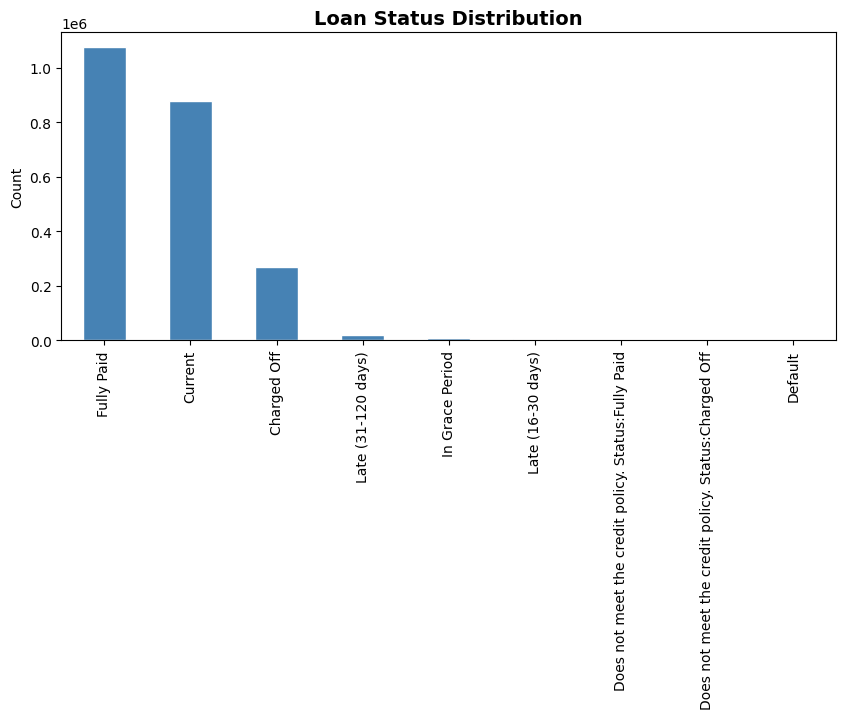

In [7]:
# quick bar chart
fig, ax = plt.subplots(figsize=(10, 4))
df['loan_status'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Loan Status Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

In [8]:
# ── 5. DEFINE DEFAULT — THE BINARY TARGET ─────────────────────────────────────
# Basel: default = charged off or formal default
# we DROP in-progress loans (current, late, grace period) — unknown outcome

# keep only resolved loans
resolved = ['Fully Paid', 'Charged Off', 'Default']
df = df[df['loan_status'].isin(resolved)].copy()

# create binary target
df['default'] = np.where(df['loan_status'].isin(['Charged Off', 'Default']), 1, 0)

print(f"Resolved loans: {len(df):,}")
print(f"\nDefault rate: {df['default'].mean()*100:.2f}%")
print(f"Defaults:     {df['default'].sum():,}")
print(f"Non-defaults: {(df['default']==0).sum():,}")

Resolved loans: 1,345,350

Default rate: 19.96%
Defaults:     268,599
Non-defaults: 1,076,751


In [9]:
# ── 6. PARSE DATES & CREATE VINTAGE YEAR ──────────────────────────────────────

df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['vintage'] = df['issue_d'].dt.year

print("Year range:", df['vintage'].min(), "—", df['vintage'].max())
print("\nLoans per year:")
print(df['vintage'].value_counts().sort_index())

Year range: 2007 — 2018

Loans per year:
vintage
2007       251
2008      1562
2009      4716
2010     11536
2011     21721
2012     53367
2013    134804
2014    223103
2015    375546
2016    293105
2017    169321
2018     56318
Name: count, dtype: int64


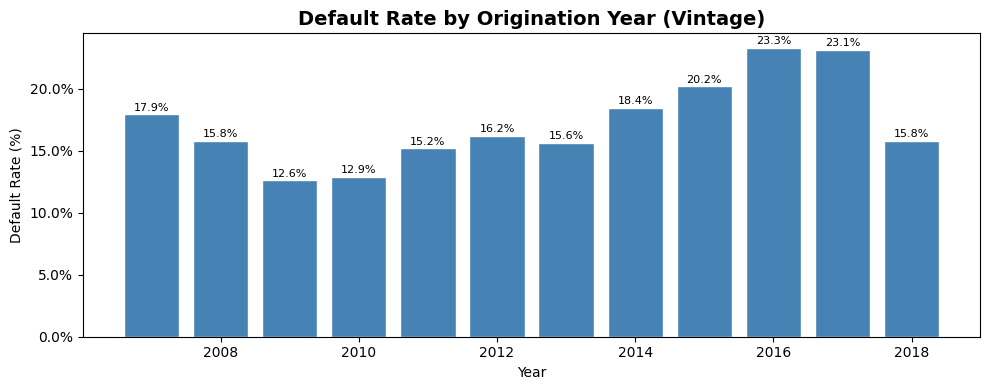


Note: recent vintages (2016-2018) look low because many loans hadn't fully matured yet


In [10]:
# default rate by year — first sanity check
dr_by_year = df.groupby('vintage')['default'].agg(['mean', 'count'])
dr_by_year.columns = ['default_rate', 'count']
dr_by_year['default_rate_pct'] = dr_by_year['default_rate'] * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(dr_by_year.index, dr_by_year['default_rate_pct'], color='steelblue', edgecolor='white')
ax.set_title('Default Rate by Origination Year (Vintage)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Default Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for i, (yr, row) in enumerate(dr_by_year.iterrows()):
    ax.text(yr, row['default_rate_pct'] + 0.3, f"{row['default_rate_pct']:.1f}%",
            ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print("\nNote: recent vintages (2016-2018) look low because many loans hadn't fully matured yet")

In [11]:
# ── 7. MISSING VALUES OVERVIEW ────────────────────────────────────────────────

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(missing_df)

                        missing_count  missing_pct
mths_since_last_delinq         678761      50.4500
emp_length                      78516       5.8400
revol_util                        857       0.0600
dti                               374       0.0300
inq_last_6mths                      1       0.0000


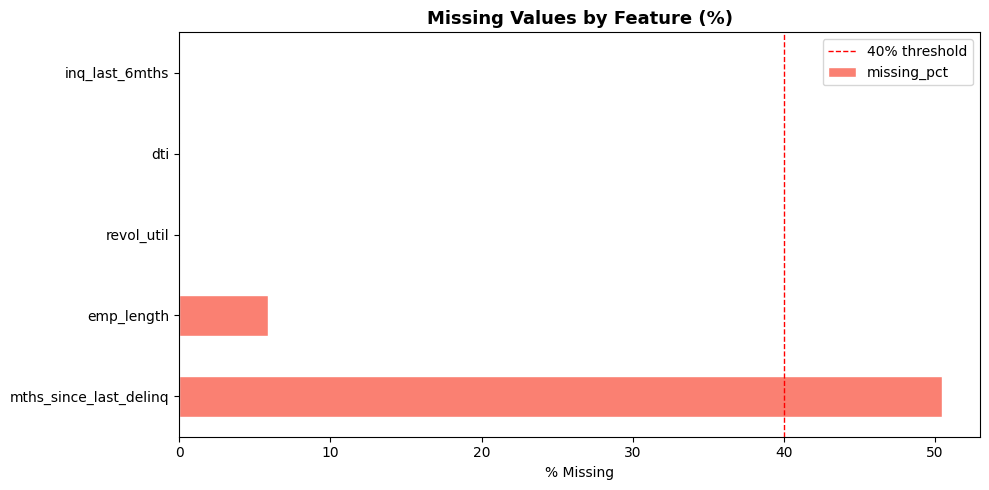

In [12]:
# visualise missing
fig, ax = plt.subplots(figsize=(10, 5))
missing_df['missing_pct'].plot(kind='barh', ax=ax, color='salmon', edgecolor='white')
ax.set_title('Missing Values by Feature (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('% Missing')
ax.axvline(x=40, color='red', linestyle='--', linewidth=1, label='40% threshold')
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# ── 8. NUMERIC SUMMARY ────────────────────────────────────────────────────────

# quick stats on the key numeric columns
num_cols = ['funded_amnt', 'int_rate', 'annual_inc', 'dti', 'revol_util', 'installment']

df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
funded_amnt,1345350.0000,14411.5500,8713.1700,500.0000,8000.0000,12000.0000,20000.0000,40000.0000
int_rate,1345350.0000,13.2400,4.7700,5.3100,9.7500,12.7400,15.9900,30.9900
annual_inc,1345350.0000,76247.5700,69924.8500,0.0000,45780.0000,65000.0000,90000.0000,10999200.0000
dti,1344976.0000,18.2800,11.1600,-1.0000,11.7900,17.6100,24.0600,999.0000
revol_util,1344493.0000,51.8100,24.5200,0.0000,33.4000,52.2000,70.7000,892.3000
installment,1345350.0000,438.0800,261.5100,4.9300,248.4800,375.4300,580.7300,1719.8300


In [14]:
# ── 9. SAVE CHECKPOINT ────────────────────────────────────────────────────────
# save the cleaned slim version so we don't have to reload the giant CSV again

df.to_parquet('lc_clean_part1.parquet', index=False)
print("Saved! Shape:", df.shape)
print("\nPart 1 complete ✓")
print("Next: Part 2 — EDA (distributions, default rates by feature, correlations)")

Saved! Shape: (1345350, 32)

Part 1 complete ✓
Next: Part 2 — EDA (distributions, default rates by feature, correlations)


In [15]:
# ── CREDIT RISK MODEL — LENDING CLUB ──────────────────────────────────────────
# Part 2: EDA — Understanding the data before modelling
# ──────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# load from part 1
df = pd.read_parquet('lc_clean_part1.parquet')
print(f"Loaded: {df.shape}")

Loaded: (1345350, 32)


In [16]:
# ── 1. CLEAN A FEW COLUMNS BEFORE PLOTTING ────────────────────────────────────

# int_rate comes as string "12.5%" in some versions — strip it
if df['int_rate'].dtype == object:
    df['int_rate'] = df['int_rate'].str.replace('%', '').astype(float)

# revol_util same issue
if df['revol_util'].dtype == object:
    df['revol_util'] = df['revol_util'].str.replace('%', '').astype(float)

# term: " 36 months" → 36
# Add a check for dtype, similar to int_rate and revol_util
if df['term'].dtype == object:
    df['term'] = df['term'].str.strip().str.replace(' months', '').astype(int)
else:
    # If it's not an object (string), assume it's already numeric and just ensure it's int
    df['term'] = df['term'].astype(int)

# emp_length: "10+ years" → 10, "< 1 year" → 0
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4,  '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8,  '9 years': 9, '10+ years': 10
}
df['emp_length_n'] = df['emp_length'].map(emp_map)  # NaN = missing = separate bin later


print("Cleaning done")
df[['int_rate', 'term', 'emp_length_n']].describe().round(2)

Cleaning done


,int_rate,term,emp_length_n
count,1345350.0000,1345350.0000,1266834.0000
mean,13.2400,41.7900,5.9700
std,4.7700,10.2700,3.6900
min,5.3100,36.0000,0.0000
25%,9.7500,36.0000,2.0000
50%,12.7400,36.0000,6.0000
75%,15.9900,36.0000,10.0000
max,30.9900,60.0000,10.0000


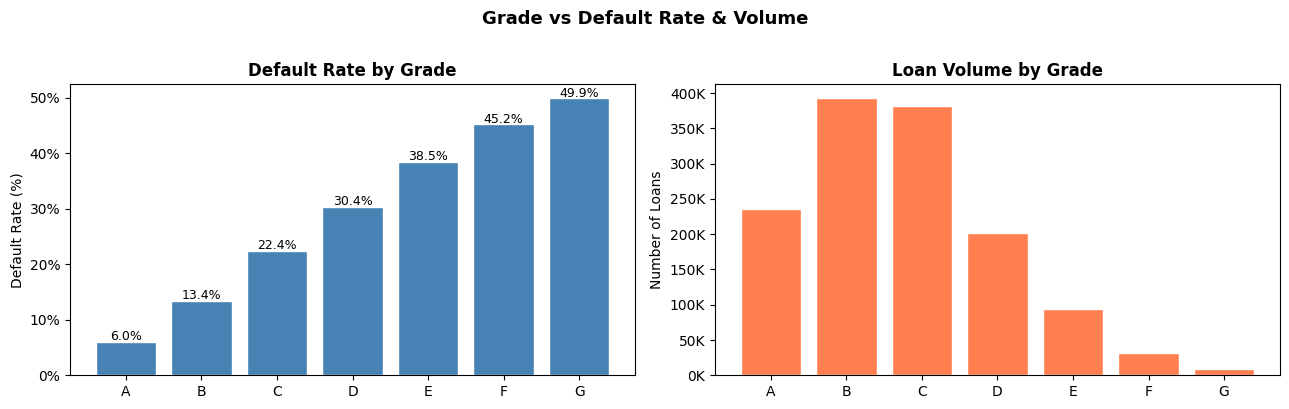

grade  default_rate  count
    A        0.0604 235095
    B        0.1339 392748
    C        0.2244 381694
    D        0.3039 200966
    E        0.3848  93656
    F        0.4520  32059
    G        0.4993   9132


In [17]:
# ── 2. DEFAULT RATE BY GRADE ───────────────────────────────────────────────────
# grade is Lending Club's own risk rating — most important categorical feature

dr_grade = df.groupby('grade')['default'].agg(['mean', 'count']).reset_index()
dr_grade.columns = ['grade', 'default_rate', 'count']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# default rate
axes[0].bar(dr_grade['grade'], dr_grade['default_rate']*100,
            color='steelblue', edgecolor='white')
axes[0].set_title('Default Rate by Grade', fontweight='bold')
axes[0].set_ylabel('Default Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for _, row in dr_grade.iterrows():
    axes[0].text(row['grade'], row['default_rate']*100 + 0.3,
                 f"{row['default_rate']*100:.1f}%", ha='center', fontsize=9)

# volume
axes[1].bar(dr_grade['grade'], dr_grade['count'],
            color='coral', edgecolor='white')
axes[1].set_title('Loan Volume by Grade', fontweight='bold')
axes[1].set_ylabel('Number of Loans')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.suptitle('Grade vs Default Rate & Volume', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(dr_grade.to_string(index=False))

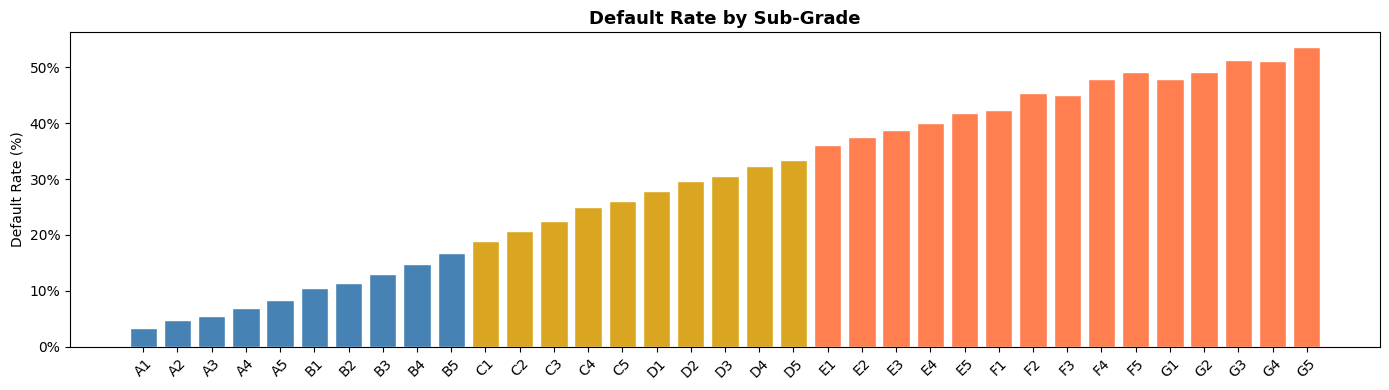

In [18]:
# ── 3. DEFAULT RATE BY SUB-GRADE ──────────────────────────────────────────────

dr_sub = df.groupby('sub_grade')['default'].mean().reset_index()
dr_sub.columns = ['sub_grade', 'default_rate']

fig, ax = plt.subplots(figsize=(14, 4))
colors = ['steelblue' if g[0] in ['A','B'] else
          'coral'     if g[0] in ['E','F','G'] else
          'goldenrod' for g in dr_sub['sub_grade']]

ax.bar(dr_sub['sub_grade'], dr_sub['default_rate']*100, color=colors, edgecolor='white')
ax.set_title('Default Rate by Sub-Grade', fontsize=13, fontweight='bold')
ax.set_ylabel('Default Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
# nice monotonic pattern — good sign for modelling

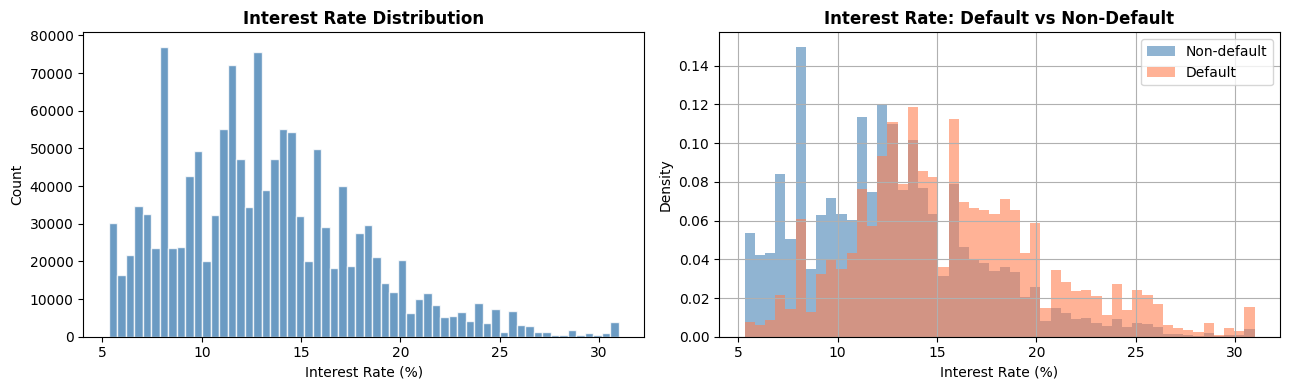

Avg int_rate — Non-default: 12.62
Avg int_rate — Default:     15.71


In [19]:
# ── 4. INTEREST RATE DISTRIBUTION ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# overall distribution
axes[0].hist(df['int_rate'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Interest Rate Distribution', fontweight='bold')
axes[0].set_xlabel('Interest Rate (%)')
axes[0].set_ylabel('Count')

# by default status
df[df['default']==0]['int_rate'].hist(bins=50, ax=axes[1], alpha=0.6,
                                       color='steelblue', label='Non-default', density=True)
df[df['default']==1]['int_rate'].hist(bins=50, ax=axes[1], alpha=0.6,
                                       color='coral', label='Default', density=True)
axes[1].set_title('Interest Rate: Default vs Non-Default', fontweight='bold')
axes[1].set_xlabel('Interest Rate (%)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Avg int_rate — Non-default:", df[df['default']==0]['int_rate'].mean().round(2))
print("Avg int_rate — Default:    ", df[df['default']==1]['int_rate'].mean().round(2))

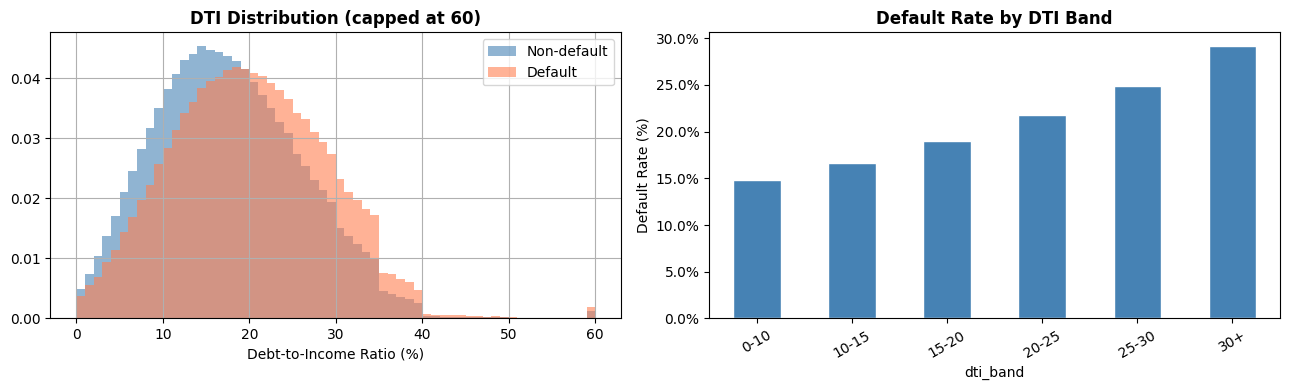

In [20]:
# ── 6. DTI DISTRIBUTION ───────────────────────────────────────────────────────

# cap extreme outliers for plotting only
dti_plot = df['dti'].clip(0, 60)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df[df['default']==0]['dti'].clip(0,60).hist(bins=60, ax=axes[0], alpha=0.6,
    color='steelblue', label='Non-default', density=True)
df[df['default']==1]['dti'].clip(0,60).hist(bins=60, ax=axes[0], alpha=0.6,
    color='coral', label='Default', density=True)
axes[0].set_title('DTI Distribution (capped at 60)', fontweight='bold')
axes[0].set_xlabel('Debt-to-Income Ratio (%)')
axes[0].legend()

# default rate by dti band
df['dti_band'] = pd.cut(df['dti'].clip(0,60),
                         bins=[0,10,15,20,25,30,60],
                         labels=['0-10','10-15','15-20','20-25','25-30','30+'])
dr_dti = df.groupby('dti_band', observed=True)['default'].mean() * 100
dr_dti.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Default Rate by DTI Band', fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

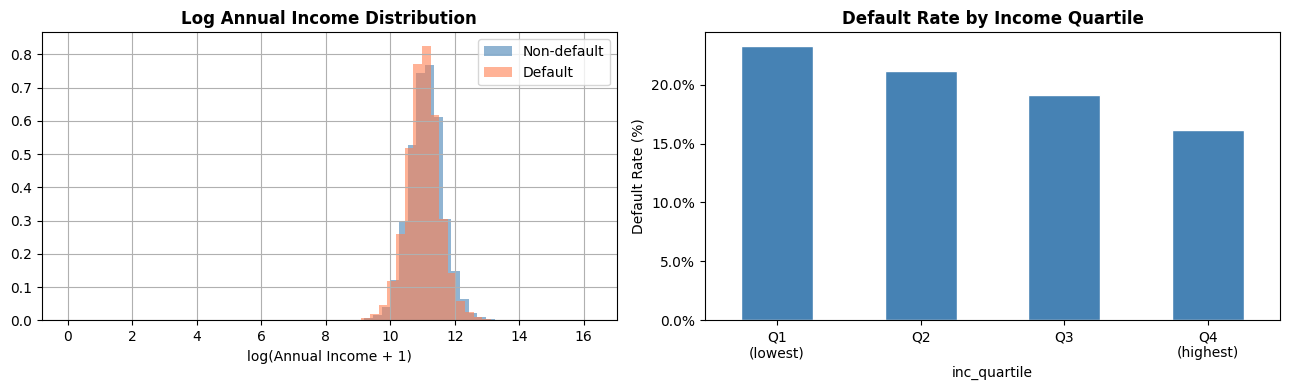

In [21]:
# ── 7. ANNUAL INCOME ──────────────────────────────────────────────────────────

# income is very skewed — use log scale
df['log_income'] = np.log1p(df['annual_inc'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df[df['default']==0]['log_income'].hist(bins=60, ax=axes[0], alpha=0.6,
    color='steelblue', label='Non-default', density=True)
df[df['default']==1]['log_income'].hist(bins=60, ax=axes[0], alpha=0.6,
    color='coral', label='Default', density=True)
axes[0].set_title('Log Annual Income Distribution', fontweight='bold')
axes[0].set_xlabel('log(Annual Income + 1)')
axes[0].legend()

# default rate by income quartile
df['inc_quartile'] = pd.qcut(df['annual_inc'].clip(0, 300000), q=4,
                              labels=['Q1\n(lowest)', 'Q2', 'Q3', 'Q4\n(highest)'])
dr_inc = df.groupby('inc_quartile', observed=True)['default'].mean() * 100
dr_inc.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Default Rate by Income Quartile', fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

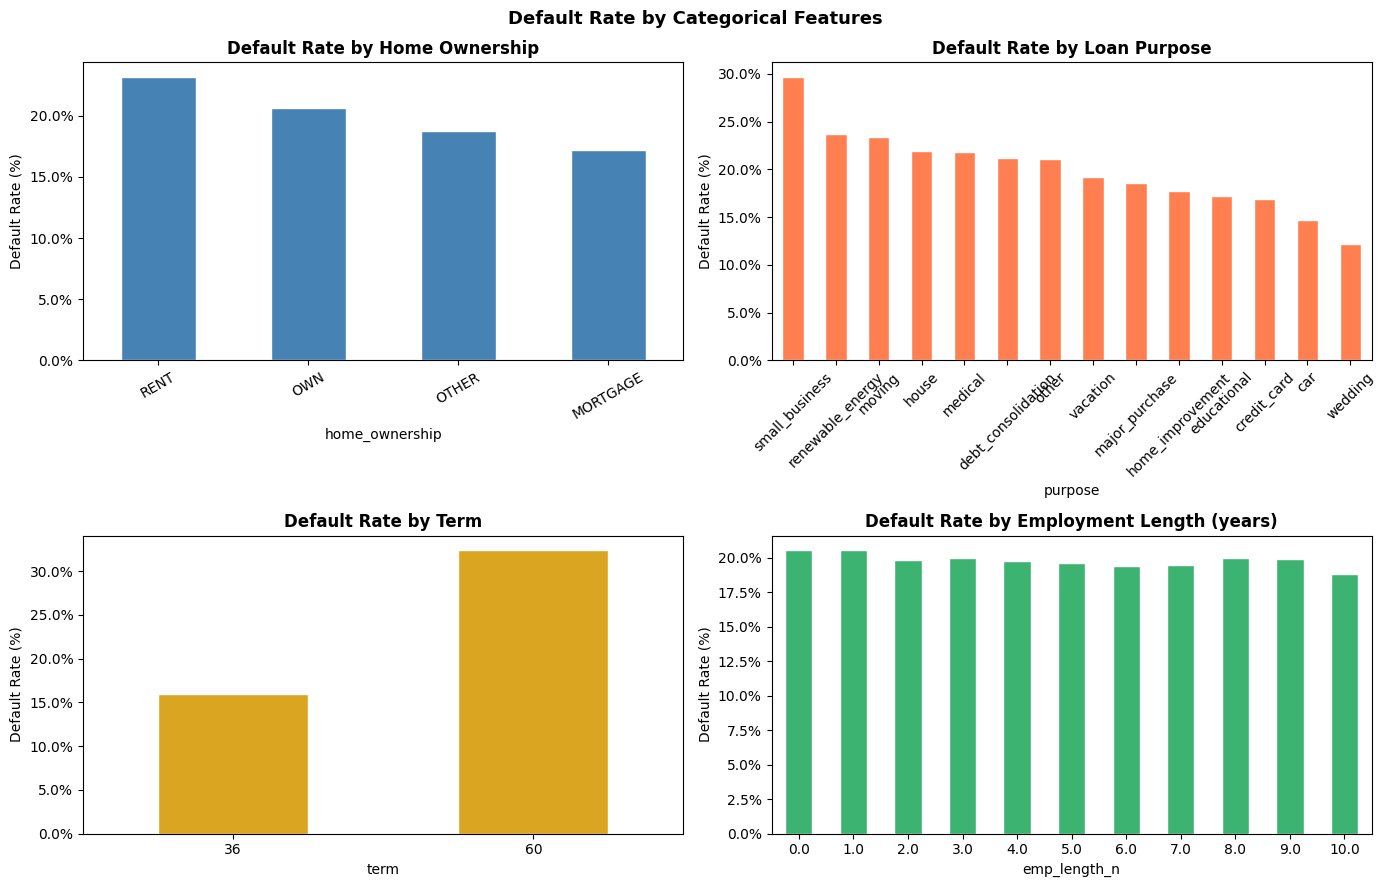

In [22]:
# ── 8. CATEGORICAL FEATURES ───────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# home ownership
dr_home = df.groupby('home_ownership')['default'].mean().sort_values(ascending=False) * 100
dr_home = dr_home[dr_home.index.isin(['RENT','OWN','MORTGAGE','OTHER'])]
dr_home.plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Default Rate by Home Ownership', fontweight='bold')
axes[0,0].set_ylabel('Default Rate (%)')
axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0,0].tick_params(axis='x', rotation=30)

# purpose
dr_purpose = df.groupby('purpose')['default'].mean().sort_values(ascending=False) * 100
dr_purpose.plot(kind='bar', ax=axes[0,1], color='coral', edgecolor='white')
axes[0,1].set_title('Default Rate by Loan Purpose', fontweight='bold')
axes[0,1].set_ylabel('Default Rate (%)')
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0,1].tick_params(axis='x', rotation=45)

# term
dr_term = df.groupby('term')['default'].mean() * 100
dr_term.plot(kind='bar', ax=axes[1,0], color='goldenrod', edgecolor='white')
axes[1,0].set_title('Default Rate by Term', fontweight='bold')
axes[1,0].set_ylabel('Default Rate (%)')
axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1,0].tick_params(axis='x', rotation=0)

# employment length
dr_emp = df.groupby('emp_length_n')['default'].mean() * 100
dr_emp.plot(kind='bar', ax=axes[1,1], color='mediumseagreen', edgecolor='white')
axes[1,1].set_title('Default Rate by Employment Length (years)', fontweight='bold')
axes[1,1].set_ylabel('Default Rate (%)')
axes[1,1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1,1].tick_params(axis='x', rotation=0)

plt.suptitle('Default Rate by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

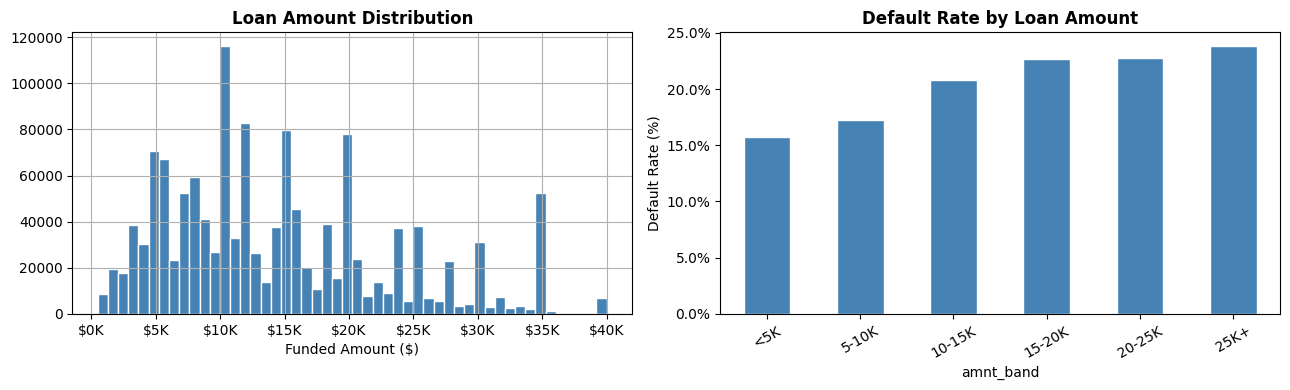

In [23]:
# ── 9. LOAN AMOUNT DISTRIBUTION ───────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['funded_amnt'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Loan Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Funded Amount ($)')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# default rate by loan amount band
df['amnt_band'] = pd.cut(df['funded_amnt'],
                          bins=[0,5000,10000,15000,20000,25000,40001],
                          labels=['<5K','5-10K','10-15K','15-20K','20-25K','25K+'])
dr_amnt = df.groupby('amnt_band', observed=True)['default'].mean() * 100
dr_amnt.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Default Rate by Loan Amount', fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

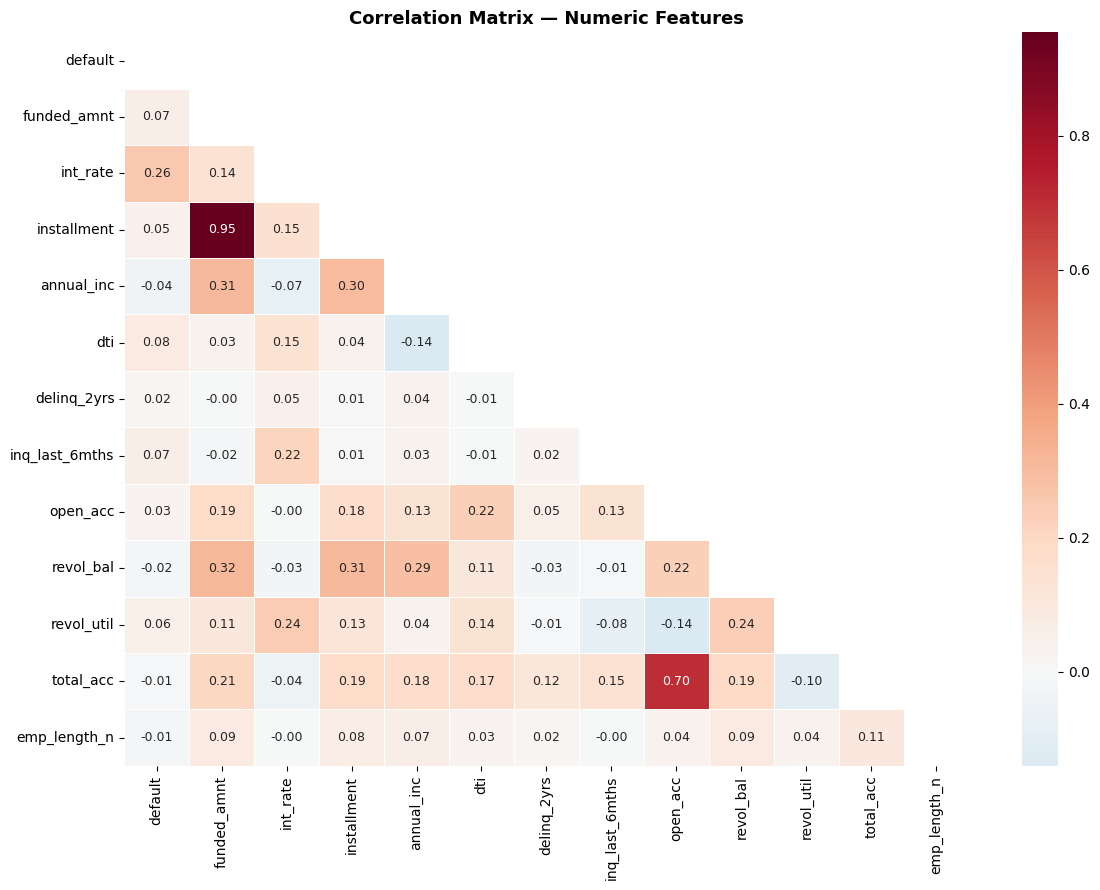


Correlation with Default (ranked):
int_rate          0.2590
dti               0.0840
funded_amnt       0.0660
inq_last_6mths    0.0650
revol_util        0.0600
installment       0.0520
open_acc          0.0280
delinq_2yrs       0.0190
total_acc        -0.0110
emp_length_n     -0.0140
revol_bal        -0.0200
annual_inc       -0.0420
Name: default, dtype: float64


In [24]:
# ── 10. CORRELATION HEATMAP ───────────────────────────────────────────────────

num_features = ['default', 'funded_amnt', 'int_rate', 'installment',
                'annual_inc', 'dti', 'delinq_2yrs',
                'inq_last_6mths', 'open_acc', 'revol_bal',
                'revol_util', 'total_acc', 'emp_length_n']

corr = df[num_features].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, annot_kws={"size": 9})
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# correlation with default — ranked
print("\nCorrelation with Default (ranked):")
print(corr['default'].drop('default').sort_values(ascending=False).round(3))

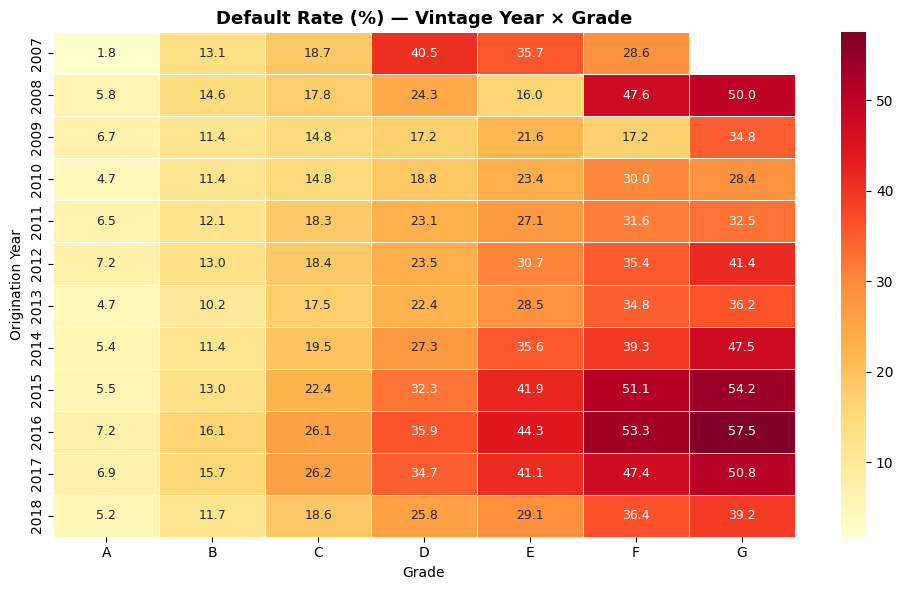

In [25]:
# ── 11. VINTAGE HEATMAP — DEFAULT RATE BY YEAR AND GRADE ──────────────────────

pivot = df.pivot_table(values='default', index='vintage',
                        columns='grade', aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, annot_kws={"size": 9})
ax.set_title('Default Rate (%) — Vintage Year × Grade', fontsize=13, fontweight='bold')
ax.set_xlabel('Grade')
ax.set_ylabel('Origination Year')
plt.tight_layout()
plt.show()
# this is the vintage analysis regulators want to see

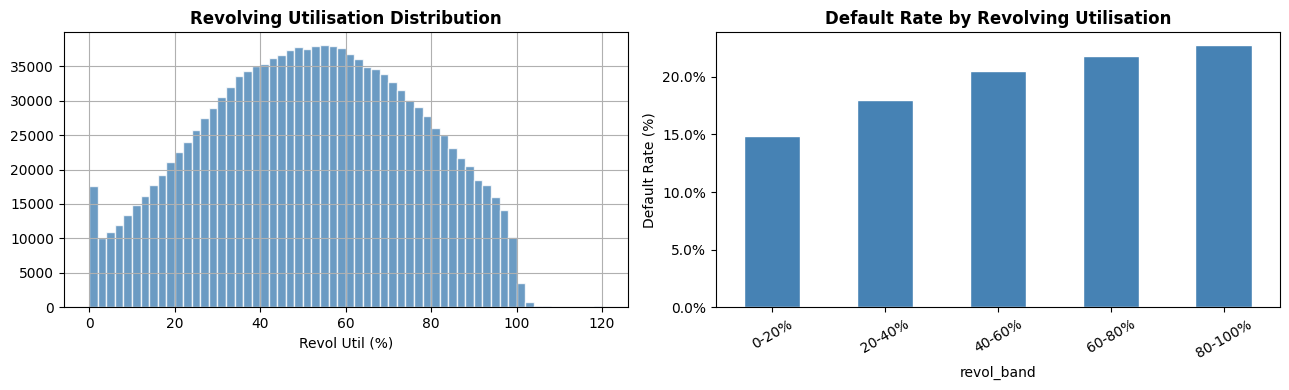

In [26]:
# ── 12. REVOLVING UTILISATION ─────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['revol_util'].clip(0, 120).hist(bins=60, ax=axes[0],
    color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Revolving Utilisation Distribution', fontweight='bold')
axes[0].set_xlabel('Revol Util (%)')

df['revol_band'] = pd.cut(df['revol_util'].clip(0,100),
                           bins=[0,20,40,60,80,100],
                           labels=['0-20%','20-40%','40-60%','60-80%','80-100%'])
dr_revol = df.groupby('revol_band', observed=True)['default'].mean() * 100
dr_revol.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Default Rate by Revolving Utilisation', fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [27]:
# ── 13. KEY EDA SUMMARY ───────────────────────────────────────────────────────

print("=" * 55)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 55)

print(f"\nDataset size (resolved loans): {len(df):,}")
print(f"Overall default rate:          {df['default'].mean()*100:.2f}%")

print("\nTop 3 riskiest purposes:")
print(df.groupby('purpose')['default'].mean()
        .sort_values(ascending=False).head(3).mul(100).round(2))

print("\nDefault rate by term:")
print(df.groupby('term')['default'].mean().mul(100).round(2))

print("\nDefault rate by grade:")
print(df.groupby('grade')['default'].mean().mul(100).round(2))

print("\nMissing values (top 5):")
miss = df.isnull().mean().mul(100).sort_values(ascending=False)
print(miss[miss > 0].head(5).round(2))

print("\nStrong predictors (|corr with default| > 0.10):")
corr_default = df[num_features].corr()['default'].drop('default')
strong = corr_default[corr_default.abs() > 0.10].sort_values(ascending=False)
print(strong.round(3))

EDA SUMMARY — KEY FINDINGS

Dataset size (resolved loans): 1,345,350
Overall default rate:          19.96%

Top 3 riskiest purposes:
purpose
small_business     29.7100
renewable_energy   23.6900
moving             23.3500
Name: default, dtype: float64

Default rate by term:
term
36   16.0000
60   32.4500
Name: default, dtype: float64

Default rate by grade:
grade
A    6.0400
B   13.3900
C   22.4400
D   30.3900
E   38.4800
F   45.2000
G   49.9300
Name: default, dtype: float64

Missing values (top 5):
mths_since_last_delinq   50.4500
emp_length                5.8400
emp_length_n              5.8400
revol_band                0.5800
dti_band                  0.0900
dtype: float64

Strong predictors (|corr with default| > 0.10):
int_rate   0.2590
Name: default, dtype: float64


In [28]:
# ── 14. SAVE CHECKPOINT ───────────────────────────────────────────────────────

# drop the helper band columns before saving — we'll re-create proper bins in part 3
drop_cols = ['fico_band', 'dti_band', 'inc_quartile', 'amnt_band',
             'revol_band', 'log_income']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

df.to_parquet('lc_clean_part2.parquet', index=False)
print(f"Saved! Shape: {df.shape}")
print("\nPart 2 complete ✓")
print("Next: Part 3 — Feature Engineering: WoE, IV, train/OOT split")

Saved! Shape: (1345350, 33)

Part 2 complete ✓
Next: Part 3 — Feature Engineering: WoE, IV, train/OOT split


In [29]:
# ── CREDIT RISK MODEL — LENDING CLUB ──────────────────────────────────────────
# Part 3: Feature Engineering — WoE, IV, Train/OOT Split
# ──────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

df = pd.read_parquet('lc_clean_part2.parquet')
print(f"Loaded: {df.shape}")

Loaded: (1345350, 33)


In [30]:
# ── 1. TRAIN / OOT SPLIT FIRST — before anything else ─────────────────────────
# CRITICAL rule: WoE must be fit on TRAIN only, then applied to OOT
# never fit on full data — that's data leakage

# 2007-2015 → train | 2016 → validation | 2017-2018 → OOT
train = df[df['vintage'] <= 2015].copy()
val   = df[df['vintage'] == 2016].copy()
oot   = df[df['vintage'] >= 2017].copy()

print(f"Train : {len(train):,}  rows  | default rate: {train['default'].mean()*100:.2f}%")
print(f"Val   : {len(val):,}   rows  | default rate: {val['default'].mean()*100:.2f}%")
print(f"OOT   : {len(oot):,}   rows  | default rate: {oot['default'].mean()*100:.2f}%")

Train : 826,606  rows  | default rate: 18.43%
Val   : 293,105   rows  | default rate: 23.29%
OOT   : 225,639   rows  | default rate: 21.29%


In [31]:
# ── 2. HANDLE MISSING VALUES ───────────────────────────────────────────────────
# strategy: numeric → median (from train only)
#           missing indicator for columns where missing has its own meaning

# columns where missing means "never happened" — keep as a separate bin in WoE
# we'll handle these naturally by binning NaN into its own bucket

# for numeric cols with random missing — fill with train median
fill_medians = {}
num_fill_cols = ['annual_inc', 'dti', 'revol_util', 'delinq_2yrs',
                 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal',
                 'total_acc', 'emp_length_n']

for col in num_fill_cols:
    median_val = train[col].median()
    fill_medians[col] = median_val
    train[col] = train[col].fillna(median_val)
    val[col]   = val[col].fillna(median_val)
    oot[col]   = oot[col].fillna(median_val)

# mths_since_last_delinq: missing = never delinquent → fill with large number
for dataset in [train, val, oot]:
    dataset['mths_since_last_delinq'] = dataset['mths_since_last_delinq'].fillna(999)

print("Missing values handled")
print("Remaining nulls in train:")
print(train[num_fill_cols].isnull().sum()[lambda x: x > 0])

Missing values handled
Remaining nulls in train:
Series([], dtype: int64)


In [32]:
# ── 3. WoE ENCODER ────────────────────────────────────────────────────────────
# we write this from scratch — simple and transparent
# fit on train, transform all splits

class WoEEncoder:
    """
    Simple WoE encoder.
    For each feature: bin it → compute WoE per bin → store mapping.
    Fit on train only, transform everything else.
    """

    def __init__(self, bins=10, min_bin_size=0.05):
        self.bins = bins
        self.min_bin_size = min_bin_size  # min % of sample per bin
        self.woe_maps = {}    # col → {bin_label: woe_value}
        self.iv_vals  = {}    # col → IV score

    def _compute_woe_iv(self, df, col, target='default'):
        """core calculation for one column"""
        temp = df[[col, target]].copy()
        temp.columns = ['x', 'y']

        total_events     = temp['y'].sum()
        total_non_events = (1 - temp['y']).sum()

        grouped = temp.groupby('x')['y'].agg(['sum', 'count'])
        grouped.columns = ['events', 'total']
        grouped['non_events'] = grouped['total'] - grouped['events']

        # avoid log(0) by clipping
        grouped['pct_events']     = (grouped['events']     / total_events).clip(1e-10)
        grouped['pct_non_events'] = (grouped['non_events'] / total_non_events).clip(1e-10)

        grouped['woe'] = np.log(grouped['pct_events'] / grouped['pct_non_events'])
        grouped['iv']  = (grouped['pct_events'] - grouped['pct_non_events']) * grouped['woe']

        iv = grouped['iv'].sum()
        woe_map = grouped['woe'].to_dict()

        return woe_map, iv

    def _bin_numeric(self, series, n_bins):
        """equal-frequency binning for numeric columns"""
        try:
            binned, bins = pd.qcut(series, q=n_bins, retbins=True,
                                   duplicates='drop', labels=False)
        except Exception:
            # fallback if too few unique values
            binned = series.rank(method='first').apply(
                lambda x: min(int(x / len(series) * n_bins), n_bins - 1)
            )
            bins = None
        return binned, bins

    def fit(self, df, numeric_cols, categorical_cols, target='default'):
        self.numeric_cols     = numeric_cols
        self.categorical_cols = categorical_cols
        self.bin_edges = {}

        # numeric columns
        for col in numeric_cols:
            temp = df[[col, target]].dropna()
            binned, edges = self._bin_numeric(temp[col], self.bins)
            temp['binned'] = binned
            self.bin_edges[col] = edges
            woe_map, iv = self._compute_woe_iv(temp[['binned', target]].rename(
                                                columns={'binned': col}), col, target)
            self.woe_maps[col] = woe_map
            self.iv_vals[col]  = iv

        # categorical columns
        for col in categorical_cols:
            temp = df[[col, target]].fillna('MISSING')
            woe_map, iv = self._compute_woe_iv(temp, col, target)
            self.woe_maps[col] = woe_map
            self.iv_vals[col]  = iv

        return self

    def transform(self, df):
        out = df.copy()

        for col in self.numeric_cols:
            edges = self.bin_edges[col]
            if edges is not None:
                binned = pd.cut(out[col], bins=edges,
                                labels=False, include_lowest=True)
            else:
                binned = out[col]
            woe_map = self.woe_maps[col]
            out[col + '_woe'] = binned.map(woe_map).fillna(0)

        for col in self.categorical_cols:
            woe_map = self.woe_maps[col]
            out[col + '_woe'] = out[col].fillna('MISSING').map(woe_map).fillna(0)

        return out

    def iv_table(self):
        iv_df = pd.DataFrame(list(self.iv_vals.items()),
                             columns=['feature', 'IV'])
        iv_df = iv_df.sort_values('IV', ascending=False).reset_index(drop=True)

        def strength(iv):
            if iv < 0.02:   return 'Useless'
            elif iv < 0.10: return 'Weak'
            elif iv < 0.30: return 'Medium'
            elif iv < 0.50: return 'Strong'
            else:           return 'Suspicious (check leakage)'
        iv_df['strength'] = iv_df['IV'].apply(strength)
        return iv_df

print("WoEEncoder class defined ✓")

WoEEncoder class defined ✓


In [33]:
# ── 4. FIT WoE ON TRAIN ───────────────────────────────────────────────────────

numeric_cols = [
    'funded_amnt', 'int_rate', 'installment', 'annual_inc',
    'dti', 'delinq_2yrs', 'inq_last_6mths',
    'open_acc', 'revol_bal', 'revol_util', 'total_acc',
    'emp_length_n', 'mths_since_last_delinq'
]

categorical_cols = [
    'grade', 'home_ownership', 'purpose', 'verification_status'
]

# term is binary (36/60) — treat as categorical
categorical_cols.append('term')

encoder = WoEEncoder(bins=10)
encoder.fit(train, numeric_cols, categorical_cols, target='default')

print("WoE encoder fitted on training data ✓")

WoE encoder fitted on training data ✓


In [34]:
# ── 5. IV TABLE — FEATURE SELECTION ───────────────────────────────────────────

iv_table = encoder.iv_table()
print(iv_table.to_string(index=False))

               feature     IV strength
                 grade 0.4725   Strong
              int_rate 0.4545   Strong
                  term 0.2403   Medium
                   dti 0.0749     Weak
   verification_status 0.0513     Weak
           funded_amnt 0.0369     Weak
            annual_inc 0.0313     Weak
           installment 0.0260     Weak
            revol_util 0.0222     Weak
        home_ownership 0.0209     Weak
               purpose 0.0208     Weak
        inq_last_6mths 0.0182  Useless
              open_acc 0.0079  Useless
          emp_length_n 0.0037  Useless
             revol_bal 0.0035  Useless
mths_since_last_delinq 0.0014  Useless
           delinq_2yrs 0.0014  Useless
             total_acc 0.0004  Useless


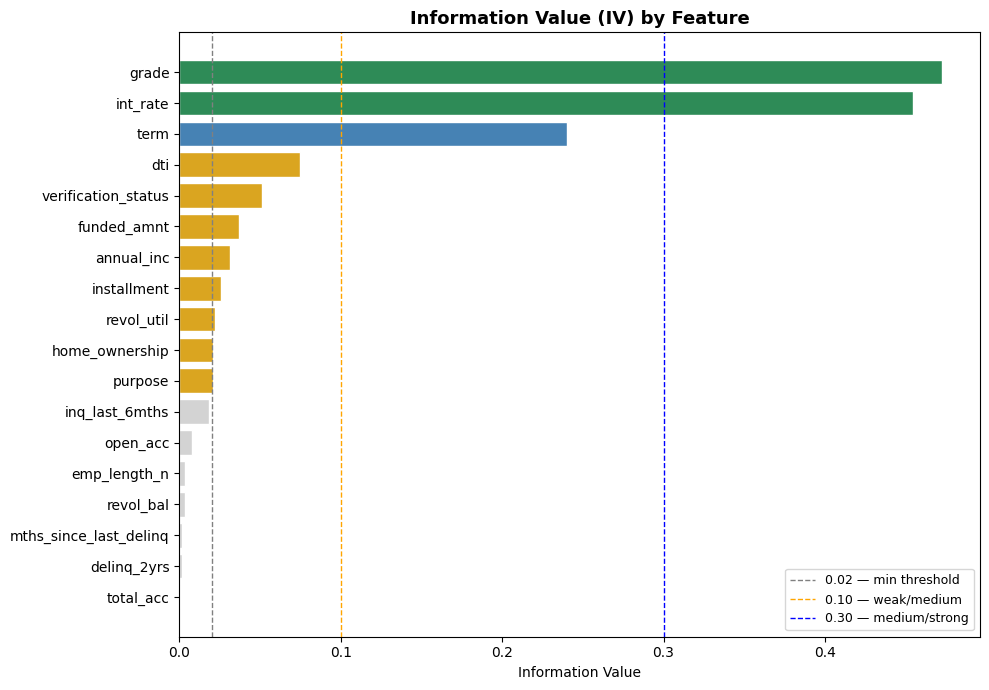

In [35]:
# IV bar chart
fig, ax = plt.subplots(figsize=(10, 7))

colors = []
for iv in iv_table['IV']:
    if iv < 0.02:   colors.append('lightgray')
    elif iv < 0.10: colors.append('goldenrod')
    elif iv < 0.30: colors.append('steelblue')
    elif iv < 0.50: colors.append('seagreen')
    else:           colors.append('coral')

ax.barh(iv_table['feature'][::-1], iv_table['IV'][::-1],
        color=colors[::-1], edgecolor='white')
ax.axvline(x=0.02, color='gray',   linestyle='--', linewidth=1, label='0.02 — min threshold')
ax.axvline(x=0.10, color='orange', linestyle='--', linewidth=1, label='0.10 — weak/medium')
ax.axvline(x=0.30, color='blue',   linestyle='--', linewidth=1, label='0.30 — medium/strong')
ax.set_title('Information Value (IV) by Feature', fontsize=13, fontweight='bold')
ax.set_xlabel('Information Value')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [36]:
# ── 6. DROP WEAK / LEAKY FEATURES ─────────────────────────────────────────────

# drop anything with IV < 0.02 — not useful
weak_features = iv_table[iv_table['IV'] < 0.02]['feature'].tolist()
print("Dropping (IV < 0.02):", weak_features)

# grade and int_rate are both very strong but highly correlated with each other
# keep grade (categorical, cleaner), drop int_rate to avoid multicollinearity
# we'll double-check with VIF in part 4
print("\nAlso dropping 'int_rate' — collinear with 'grade' (both encode risk rating)")
print("Keeping 'installment' — it reflects both amount AND rate, adds marginal info")

# final selected features
selected_numeric = [c for c in numeric_cols
                    if c not in weak_features + ['int_rate']]
selected_categorical = [c for c in categorical_cols
                        if c not in weak_features]

print(f"\nSelected numeric features    : {len(selected_numeric)}")
print(f"Selected categorical features: {len(selected_categorical)}")
print("\nNumeric:", selected_numeric)
print("Categorical:", selected_categorical)

Dropping (IV < 0.02): ['inq_last_6mths', 'open_acc', 'emp_length_n', 'revol_bal', 'mths_since_last_delinq', 'delinq_2yrs', 'total_acc']

Also dropping 'int_rate' — collinear with 'grade' (both encode risk rating)
Keeping 'installment' — it reflects both amount AND rate, adds marginal info

Selected numeric features    : 5
Selected categorical features: 5

Numeric: ['funded_amnt', 'installment', 'annual_inc', 'dti', 'revol_util']
Categorical: ['grade', 'home_ownership', 'purpose', 'verification_status', 'term']


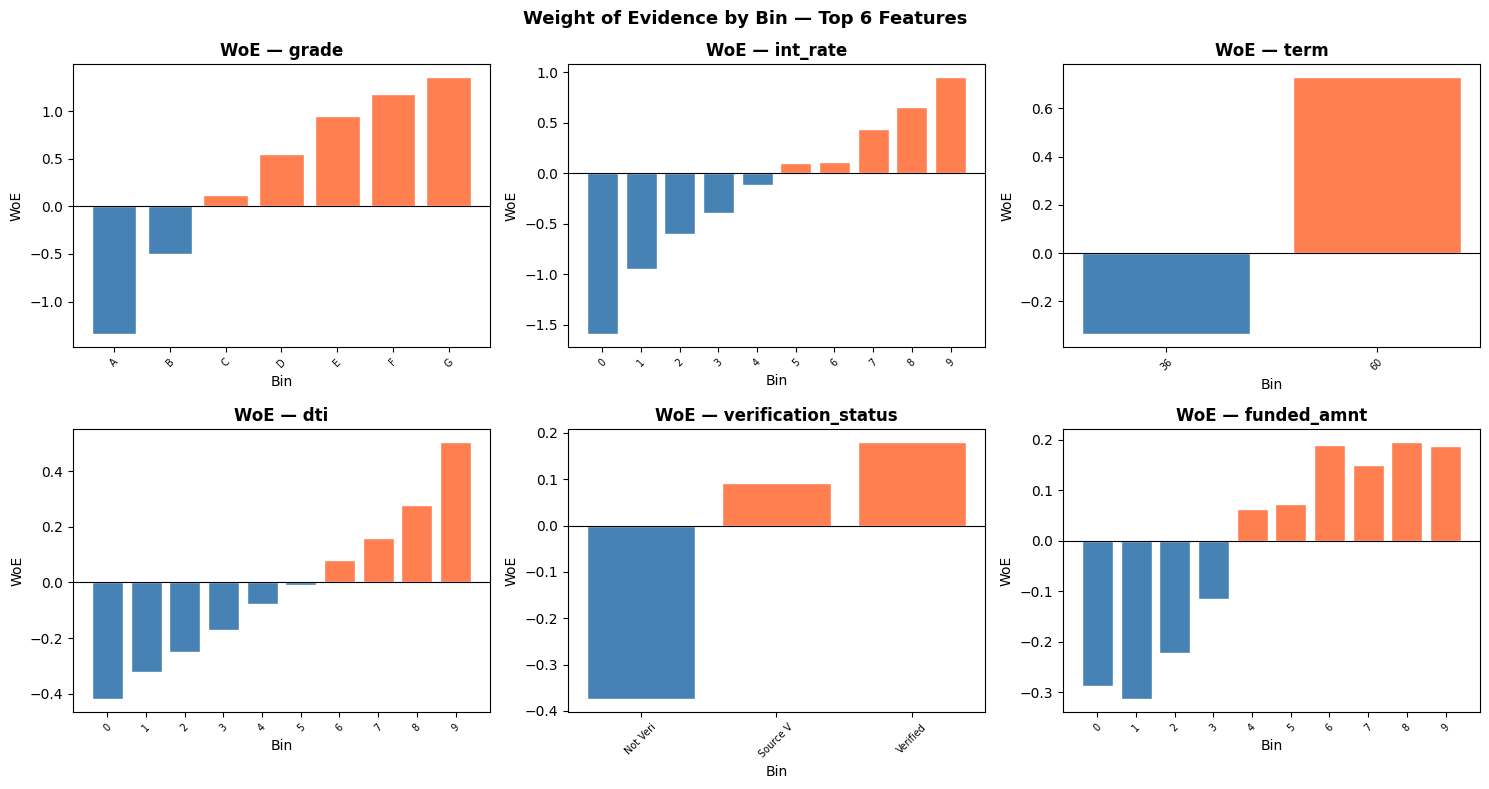

In [37]:
# ── 8. PLOT WoE VALUES FOR TOP FEATURES ───────────────────────────────────────
# shows the risk profile within each bin — regulators love these plots

top_features = iv_table.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    woe_map = encoder.woe_maps[col]
    bins_   = list(woe_map.keys())
    woes    = list(woe_map.values())

    colors_ = ['coral' if w > 0 else 'steelblue' for w in woes]
    axes[i].bar(range(len(bins_)), woes, color=colors_, edgecolor='white')
    axes[i].axhline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'WoE — {col}', fontweight='bold')
    axes[i].set_xlabel('Bin')
    axes[i].set_ylabel('WoE')
    axes[i].set_xticks(range(len(bins_)))
    axes[i].set_xticklabels([str(b)[:8] for b in bins_], rotation=45, fontsize=7)

plt.suptitle('Weight of Evidence by Bin — Top 6 Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# positive WoE = higher default risk in that bin
# negative WoE = lower default risk
# monotonic trend = well-behaved variable

In [38]:
# ── 9. CHECK MONOTONICITY OF WoE ──────────────────────────────────────────────
# Basel requirement: WoE should be monotonically increasing (risk rises with bin)
# for numeric variables. Violations suggest the binning needs adjustment.

print("Monotonicity check (numeric features):")
print("-" * 40)

for col in selected_numeric:
    woe_map = encoder.woe_maps[col]
    woes = list(woe_map.values())
    diffs = [woes[i+1] - woes[i] for i in range(len(woes)-1)]

    # check if mostly increasing or mostly decreasing
    increasing = sum(d > 0 for d in diffs)
    decreasing = sum(d < 0 for d in diffs)
    total      = len(diffs)

    if increasing >= total * 0.8:
        direction = "↑ monotone increasing"
    elif decreasing >= total * 0.8:
        direction = "↓ monotone decreasing"
    else:
        direction = "⚠ non-monotone — review binning"

    print(f"  {col:<28} {direction}")

Monotonicity check (numeric features):
----------------------------------------
  funded_amnt                  ⚠ non-monotone — review binning
  installment                  ⚠ non-monotone — review binning
  annual_inc                   ↓ monotone decreasing
  dti                          ↑ monotone increasing
  revol_util                   ↑ monotone increasing


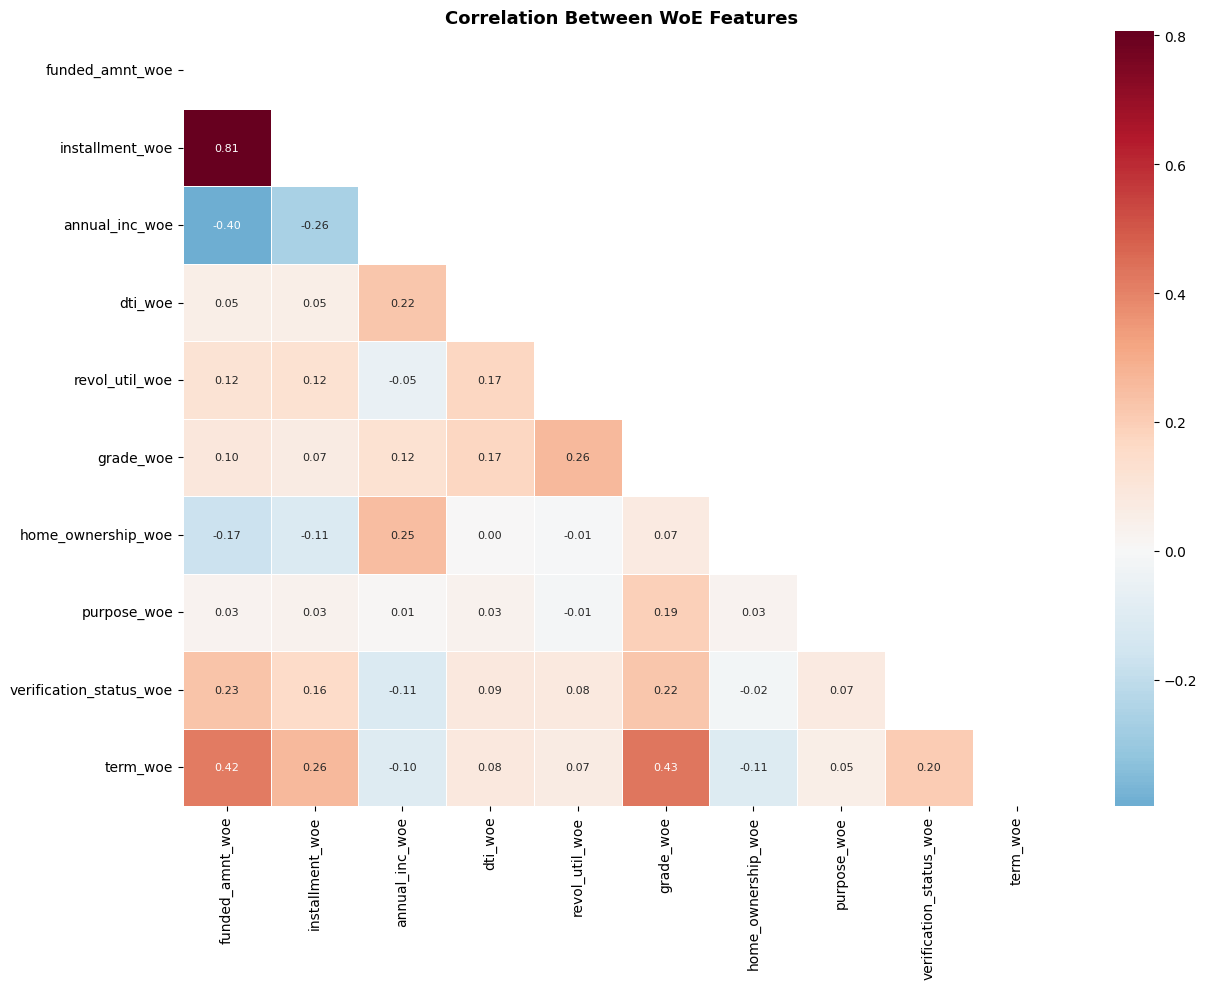


Highly correlated pairs (|r| > 0.70):
  funded_amnt_woe  ↔  installment_woe  :  r = 0.806


In [39]:
# ── 10. CORRELATION BETWEEN WoE FEATURES ──────────────────────────────────────
# check for multicollinearity before feeding to logistic regression

# Transform the datasets to get WoE values
train_woe = encoder.transform(train)
val_woe   = encoder.transform(val)
oot_woe   = encoder.transform(oot)

# Define the list of WoE features
woe_features = [f'{col}_woe' for col in selected_numeric + selected_categorical]

woe_corr = train_woe[woe_features].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(woe_corr, dtype=bool))
sns.heatmap(woe_corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.4, annot_kws={"size": 8})
ax.set_title('Correlation Between WoE Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# flag high correlations
print("\nHighly correlated pairs (|r| > 0.70):")
for i in range(len(woe_features)):
    for j in range(i+1, len(woe_features)):
        r = woe_corr.iloc[i, j]
        if abs(r) > 0.70:
            print(f"  {woe_features[i]}  ↔  {woe_features[j]}  :  r = {r:.3f}")

In [40]:
# ── 11. FINAL FEATURE SET ─────────────────────────────────────────────────────

# if any pair has |r| > 0.85, drop the one with lower IV
# adjust this list based on what the correlation check above shows

# example — if installment_woe and funded_amnt_woe are very correlated:
# drop installment_woe (lower IV), keep funded_amnt_woe

# run this after inspecting the heatmap above
high_corr_drops = []  # add column names here if needed e.g. ['installment_woe']

final_woe_features = [f for f in woe_features if f not in high_corr_drops]

print(f"Final WoE features for modelling: {len(final_woe_features)}")
print(final_woe_features)

Final WoE features for modelling: 10
['funded_amnt_woe', 'installment_woe', 'annual_inc_woe', 'dti_woe', 'revol_util_woe', 'grade_woe', 'home_ownership_woe', 'purpose_woe', 'verification_status_woe', 'term_woe']


In [41]:
# ── 12. PREPARE FINAL MODEL MATRICES ──────────────────────────────────────────

X_train = train_woe[final_woe_features]
y_train = train_woe['default']

X_val   = val_woe[final_woe_features]
y_val   = val_woe['default']

X_oot   = oot_woe[final_woe_features]
y_oot   = oot_woe['default']

print("Model matrices ready:")
print(f"  X_train: {X_train.shape}  |  y_train default rate: {y_train.mean()*100:.2f}%")
print(f"  X_val  : {X_val.shape}   |  y_val   default rate: {y_val.mean()*100:.2f}%")
print(f"  X_oot  : {X_oot.shape}   |  y_oot   default rate: {y_oot.mean()*100:.2f}%")

# quick sanity check — no nulls in WoE features
print(f"\nNulls in X_train: {X_train.isnull().sum().sum()}")
print(f"Nulls in X_oot  : {X_oot.isnull().sum().sum()}")

Model matrices ready:
  X_train: (826606, 10)  |  y_train default rate: 18.43%
  X_val  : (293105, 10)   |  y_val   default rate: 23.29%
  X_oot  : (225639, 10)   |  y_oot   default rate: 21.29%

Nulls in X_train: 0
Nulls in X_oot  : 0


In [42]:
# ── 13. SAVE EVERYTHING ───────────────────────────────────────────────────────

import pickle

# save datasets
train_woe.to_parquet('train_woe.parquet', index=False)
val_woe.to_parquet('val_woe.parquet',     index=False)
oot_woe.to_parquet('oot_woe.parquet',     index=False)

# save encoder and feature list — need these for scoring new loans later
with open('woe_encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

with open('final_woe_features.pkl', 'wb') as f:
    pickle.dump(final_woe_features, f)

print("Saved: train_woe, val_woe, oot_woe, encoder, feature list")
print("\nPart 3 complete ✓")
print("Next: Part 4 — PD Model: Logistic Regression, Scorecard, Calibration, Gini/KS/AUROC")

Saved: train_woe, val_woe, oot_woe, encoder, feature list

Part 3 complete ✓
Next: Part 4 — PD Model: Logistic Regression, Scorecard, Calibration, Gini/KS/AUROC


In [43]:
# ── CREDIT RISK MODEL — LENDING CLUB ──────────────────────────────────────────
# Part 4: PD Model — Logistic Regression, Scorecard, Calibration, Validation
# ──────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pickle
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve,
                             brier_score_loss, confusion_matrix)
from sklearn.calibration import calibration_curve
import scipy.stats as stats

warnings.filterwarnings('ignore')

# load
train_woe = pd.read_parquet('train_woe.parquet')
val_woe   = pd.read_parquet('val_woe.parquet')
oot_woe   = pd.read_parquet('oot_woe.parquet')

with open('final_woe_features.pkl', 'rb') as f:
    final_woe_features = pickle.load(f)

X_train = train_woe[final_woe_features]
y_train = train_woe['default']
X_val   = val_woe[final_woe_features]
y_val   = val_woe['default']
X_oot   = oot_woe[final_woe_features]
y_oot   = oot_woe['default']

print(f"Train: {X_train.shape} | Val: {X_val.shape} | OOT: {X_oot.shape}")

Train: (826606, 10) | Val: (293105, 10) | OOT: (225639, 10)


In [44]:
# VIF Check

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()
vif_df["Feature"] = X_train.columns

vif_df["VIF"] = [
    variance_inflation_factor(X_train.values, i)
    for i in range(X_train.shape[1])
]

print("\nVariance Inflation Factor (VIF)")
display(vif_df.sort_values("VIF", ascending=False))


Variance Inflation Factor (VIF)


,Feature,VIF
0,funded_amnt_woe,3.8384
1,installment_woe,2.9896
9,term_woe,1.5822
5,grade_woe,1.5306
2,annual_inc_woe,1.3967
3,dti_woe,1.1369
4,revol_util_woe,1.1337
8,verification_status_woe,1.1225
6,home_ownership_woe,1.0915
7,purpose_woe,1.0500


## Multicollinearity Assessment

Variance Inflation Factor (VIF) was calculated for all selected WoE-transformed predictors.

All variables exhibited VIF values below the commonly accepted threshold of 5, indicating that multicollinearity is not a material concern in the final model.

The highest VIF was observed for funded_amnt_woe (3.84), which remains within acceptable limits.

In [45]:
# ── 1. LOGISTIC REGRESSION ────────────────────────────────────────────────────
# C = regularisation strength (1/lambda) — higher C = less regularisation
# liblinear solver works well for small-medium tabular data
# class_weight balanced handles the default/non-default imbalance

lr = LogisticRegression(C=1.0, solver='liblinear',
                         class_weight='balanced', max_iter=1000,
                         random_state=42)
lr.fit(X_train, y_train)

print("Model fitted ✓")
print(f"\nIntercept: {lr.intercept_[0]:.4f}")
print("\nCoefficients:")
coef_df = pd.DataFrame({
    'feature'    : final_woe_features,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=False)
print(coef_df.to_string(index=False))

Model fitted ✓

Intercept: 0.0008

Coefficients:
                feature  coefficient
     home_ownership_woe       0.9066
         annual_inc_woe       0.7626
              grade_woe       0.7489
               term_woe       0.5424
                dti_woe       0.5160
        installment_woe       0.4109
verification_status_woe       0.2294
            purpose_woe       0.1982
        funded_amnt_woe       0.0362
         revol_util_woe      -0.0342


In [46]:
# ── 2. CHECK COEFFICIENT SIGNS ────────────────────────────────────────────────
# all coefficients on WoE features should be POSITIVE
# because higher WoE already means higher risk — so coef must reinforce that
# a negative coef would mean the model is working against the WoE direction

print("Coefficient sign check:")
print("-" * 45)
all_positive = True
for _, row in coef_df.iterrows():
    sign = "✓" if row['coefficient'] > 0 else "⚠ NEGATIVE — review"
    if row['coefficient'] < 0:
        all_positive = False
    print(f"  {row['feature']:<35} {row['coefficient']:>8.4f}  {sign}")

print()
if all_positive:
    print("All coefficients positive ✓ — model is monotone consistent")
else:
    print("Some negative coefficients — consider dropping those features")
    print("Negative coef on WoE feature = multicollinearity or weak feature")

Coefficient sign check:
---------------------------------------------
  home_ownership_woe                    0.9066  ✓
  annual_inc_woe                        0.7626  ✓
  grade_woe                             0.7489  ✓
  term_woe                              0.5424  ✓
  dti_woe                               0.5160  ✓
  installment_woe                       0.4109  ✓
  verification_status_woe               0.2294  ✓
  purpose_woe                           0.1982  ✓
  funded_amnt_woe                       0.0362  ✓
  revol_util_woe                       -0.0342  ⚠ NEGATIVE — review

Some negative coefficients — consider dropping those features
Negative coef on WoE feature = multicollinearity or weak feature


In [47]:
# ── 3. GET PREDICTED PROBABILITIES ───────────────────────────────────────────

# raw predicted PD from model
train_woe['pd_raw'] = lr.predict_proba(X_train)[:, 1]
val_woe['pd_raw']   = lr.predict_proba(X_val)[:, 1]
oot_woe['pd_raw']   = lr.predict_proba(X_oot)[:, 1]

print("Predicted PD summary:")
for name, ds in [('Train', train_woe), ('Val', val_woe), ('OOT', oot_woe)]:
    print(f"  {name}: mean PD = {ds['pd_raw'].mean()*100:.2f}%  "
          f"| actual DR = {ds['default'].mean()*100:.2f}%")

Predicted PD summary:
  Train: mean PD = 45.82%  | actual DR = 18.43%
  Val: mean PD = 45.02%  | actual DR = 23.29%
  OOT: mean PD = 45.05%  | actual DR = 21.29%


In [48]:
# ── 4. GINI, AUROC, KS ────────────────────────────────────────────────────────

def discrimination_metrics(y_true, y_score, label=''):
    auroc = roc_auc_score(y_true, y_score)
    gini  = 2 * auroc - 1

    # KS
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ks = (tpr - fpr).max()

    print(f"  {label:<8} AUROC={auroc:.4f}  Gini={gini:.4f}  KS={ks:.4f}")
    return auroc, gini, ks

print("Discrimination metrics:")
auroc_tr, gini_tr, ks_tr = discrimination_metrics(y_train, train_woe['pd_raw'], 'Train')
auroc_v,  gini_v,  ks_v  = discrimination_metrics(y_val,   val_woe['pd_raw'],   'Val')
auroc_oo, gini_oo, ks_oo = discrimination_metrics(y_oot,   oot_woe['pd_raw'],   'OOT')

print(f"\n  Gini drop Train→OOT: {(gini_tr - gini_oo)*100:.1f} pp")
print("  (acceptable if < 5 pp — larger gap suggests overfitting)")

Discrimination metrics:
  Train    AUROC=0.7089  Gini=0.4178  KS=0.3037
  Val      AUROC=0.6999  Gini=0.3998  KS=0.2888
  OOT      AUROC=0.6918  Gini=0.3836  KS=0.2798

  Gini drop Train→OOT: 3.4 pp
  (acceptable if < 5 pp — larger gap suggests overfitting)


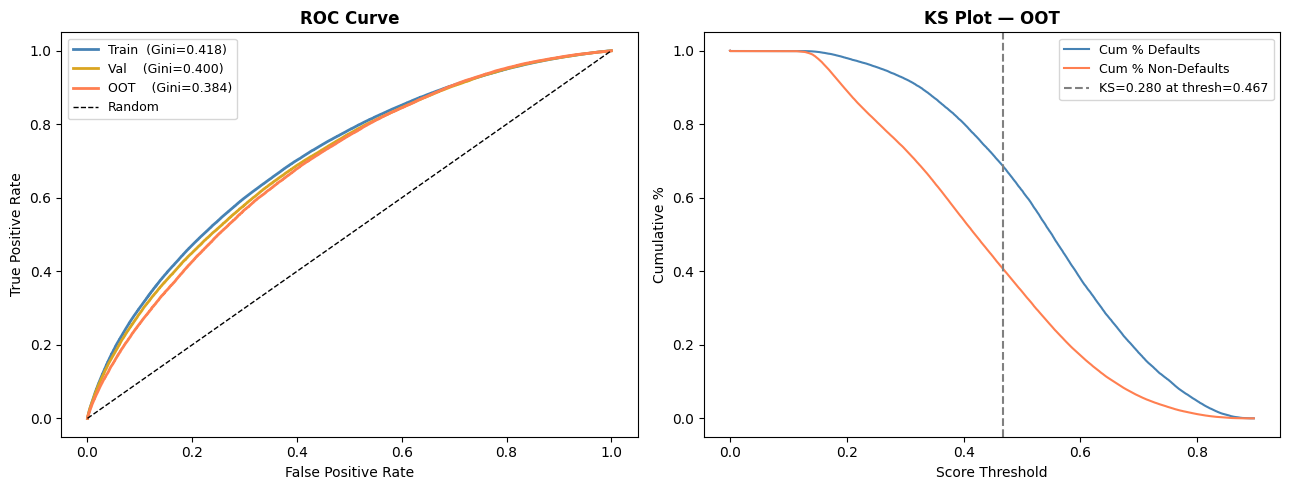

In [49]:
# ── 5. ROC CURVE PLOT ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
for y, scores, label, color in [
    (y_train, train_woe['pd_raw'], f'Train  (Gini={gini_tr:.3f})', 'steelblue'),
    (y_val,   val_woe['pd_raw'],   f'Val    (Gini={gini_v:.3f})',  'goldenrod'),
    (y_oot,   oot_woe['pd_raw'],   f'OOT    (Gini={gini_oo:.3f})', 'coral'),
]:
    fpr, tpr, _ = roc_curve(y, scores)
    axes[0].plot(fpr, tpr, label=label, linewidth=2, color=color)

axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)

# KS plot — OOT only
fpr_oot, tpr_oot, thresh = roc_curve(y_oot, oot_woe['pd_raw'])
ks_idx = (tpr_oot - fpr_oot).argmax()
axes[1].plot(thresh[::-1], tpr_oot[::-1],  color='steelblue', label='Cum % Defaults')
axes[1].plot(thresh[::-1], fpr_oot[::-1],  color='coral',     label='Cum % Non-Defaults')
axes[1].axvline(x=thresh[ks_idx], color='gray', linestyle='--',
                label=f'KS={ks_oo:.3f} at thresh={thresh[ks_idx]:.3f}')
axes[1].set_title('KS Plot — OOT', fontweight='bold')
axes[1].set_xlabel('Score Threshold')
axes[1].set_ylabel('Cumulative %')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [50]:
# ==========================
# Population Stability Index
# ==========================

def calculate_psi(expected, actual, buckets=10):

    breakpoints = np.percentile(
        expected,
        np.arange(0, buckets + 1) / buckets * 100
    )

    expected_counts = np.histogram(expected, breakpoints)[0]
    actual_counts = np.histogram(actual, breakpoints)[0]

    expected_pct = expected_counts / len(expected)
    actual_pct = actual_counts / len(actual)

    expected_pct = np.where(expected_pct == 0, 0.0001, expected_pct)
    actual_pct = np.where(actual_pct == 0, 0.0001, actual_pct)

    psi = np.sum(
        (actual_pct - expected_pct)
        * np.log(actual_pct / expected_pct)
    )

    return psi

psi_score = calculate_psi(y_train, y_oot)

print(f"\nPSI Score : {psi_score:.4f}")

if psi_score < 0.10:
    print("Population is Stable")
elif psi_score < 0.25:
    print("Moderate Population Drift")
else:
    print("Significant Population Drift")


PSI Score : 0.0052
Population is Stable


In [51]:
# ── 6. SCORECARD SCALING ──────────────────────────────────────────────────────
# converts log-odds to integer points
# PDO = 20 (score increases 20 pts when odds double)
# base score = 600 at odds of 1:20 (PD ~ 4.8%)

PDO    = 20
OFFSET = 600
ODDS_0 = 20   # odds at base score

factor = PDO / np.log(2)
offset_calc = OFFSET - factor * np.log(ODDS_0)

def log_odds_to_score(log_odds):
    return offset_calc + factor * log_odds

# log-odds from model (before sigmoid)
def get_log_odds(model, X):
    return X.values @ model.coef_[0] + model.intercept_[0]

train_woe['log_odds'] = get_log_odds(lr, X_train)
val_woe['log_odds']   = get_log_odds(lr, X_val)
oot_woe['log_odds']   = get_log_odds(lr, X_oot)

train_woe['score'] = log_odds_to_score(train_woe['log_odds'])
val_woe['score']   = log_odds_to_score(val_woe['log_odds'])
oot_woe['score']   = log_odds_to_score(oot_woe['log_odds'])

print("Score summary:")
for name, ds in [('Train', train_woe), ('Val', val_woe), ('OOT', oot_woe)]:
    print(f"  {name}: min={ds['score'].min():.0f}  "
          f"max={ds['score'].max():.0f}  "
          f"mean={ds['score'].mean():.0f}")

Score summary:
  Train: min=223  max=575  mean=508
  Val: min=191  max=574  mean=507
  OOT: min=181  max=576  mean=507


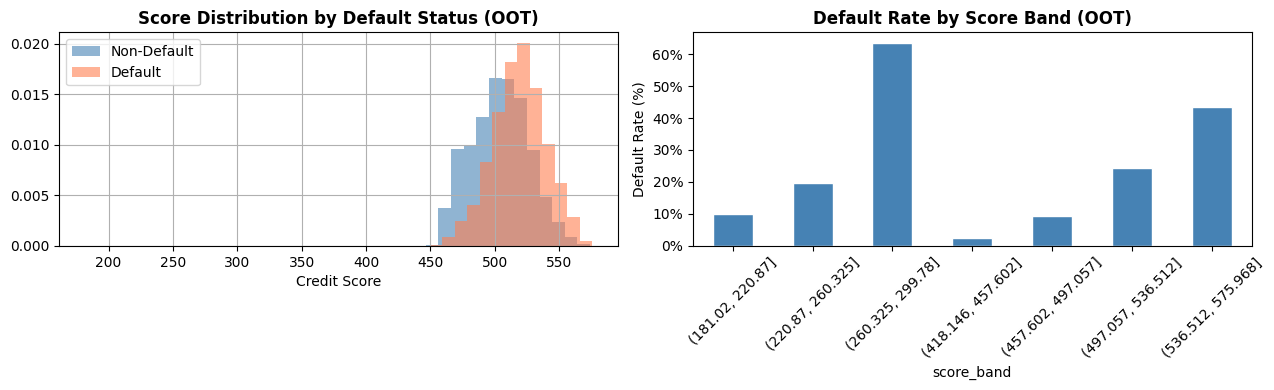

In [52]:
# ── 7. SCORE DISTRIBUTION PLOT ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# score distribution by default status (OOT)
oot_woe[oot_woe['default']==0]['score'].hist(
    bins=40, ax=axes[0], alpha=0.6, color='steelblue',
    label='Non-Default', density=True)
oot_woe[oot_woe['default']==1]['score'].hist(
    bins=40, ax=axes[0], alpha=0.6, color='coral',
    label='Default', density=True)
axes[0].set_title('Score Distribution by Default Status (OOT)',
                  fontweight='bold')
axes[0].set_xlabel('Credit Score')
axes[0].legend()

# default rate by score band
oot_woe['score_band'] = pd.cut(oot_woe['score'], bins=10)
dr_score = oot_woe.groupby('score_band', observed=True)['default'].mean() * 100
dr_score.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Default Rate by Score Band (OOT)', fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
# separation between the two distributions = discrimination power

In [53]:
# ── 8. CALIBRATION ────────────────────────────────────────────────────────────
# raw model PD vs actual default rate — are the numbers accurate?

def calibrate_pd(train_scores, train_labels, new_scores):
    """
    Platt scaling — fit a logistic on predicted prob vs actual label.
    Then use that to transform raw PD into calibrated PD.
    """
    from sklearn.linear_model import LogisticRegression
    cal_model = LogisticRegression()
    cal_model.fit(train_scores.values.reshape(-1, 1), train_labels)
    return cal_model.predict_proba(new_scores.values.reshape(-1, 1))[:, 1]

# fit calibration on val, apply to OOT
train_woe['pd_cal'] = calibrate_pd(train_woe['pd_raw'], y_train, train_woe['pd_raw'])
val_woe['pd_cal']   = calibrate_pd(train_woe['pd_raw'], y_train, val_woe['pd_raw'])
oot_woe['pd_cal']   = calibrate_pd(train_woe['pd_raw'], y_train, oot_woe['pd_raw'])

print("Calibration check — mean predicted PD vs actual DR:")
for name, ds, y in [('Train', train_woe, y_train),
                    ('Val',   val_woe,   y_val),
                    ('OOT',   oot_woe,   y_oot)]:
    print(f"  {name}: raw PD={ds['pd_raw'].mean()*100:.2f}%  "
          f"cal PD={ds['pd_cal'].mean()*100:.2f}%  "
          f"actual DR={y.mean()*100:.2f}%")

Calibration check — mean predicted PD vs actual DR:
  Train: raw PD=45.82%  cal PD=18.42%  actual DR=18.43%
  Val: raw PD=45.02%  cal PD=17.79%  actual DR=23.29%
  OOT: raw PD=45.05%  cal PD=17.84%  actual DR=21.29%


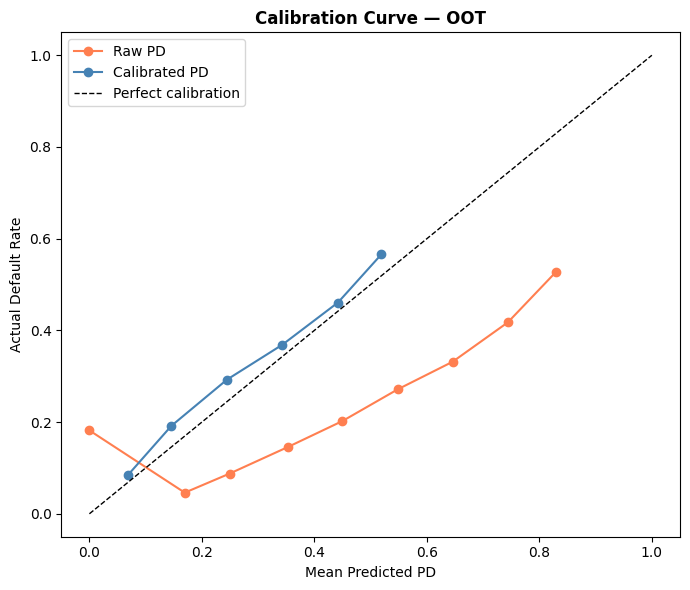

In [55]:
# calibration curve plot
fig, ax = plt.subplots(figsize=(7, 6))

for scores, label, color in [
    (oot_woe['pd_raw'], 'Raw PD',        'coral'),
    (oot_woe['pd_cal'], 'Calibrated PD', 'steelblue'),
]:
    prob_true, prob_pred = calibration_curve(y_oot, scores, n_bins=10)
    ax.plot(prob_pred, prob_true, marker='o', label=label, color=color)

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Perfect calibration')
ax.set_title('Calibration Curve — OOT', fontweight='bold')
ax.set_xlabel('Mean Predicted PD')
ax.set_ylabel('Actual Default Rate')
ax.legend()
plt.tight_layout()
plt.show()
# points on the diagonal = well calibrated
# above diagonal = model underestimates risk
# below diagonal = model overestimates risk

In [56]:
# ── 9. MARGIN OF CONSERVATISM ─────────────────────────────────────────────────
# Basel: add MoC buffer to account for estimation uncertainty
# MoC = Z(95%) × standard error of observed default rate

def add_moc(pd_estimate, n_observations, confidence=0.95):
    z = stats.norm.ppf(confidence)
    se = np.sqrt(pd_estimate * (1 - pd_estimate) / n_observations)
    moc = z * se
    return pd_estimate + moc, moc

# apply per rating grade (score decile)
oot_woe['score_decile'] = pd.qcut(oot_woe['score'], q=10, labels=False,
                                   duplicates='drop')
grade_stats = oot_woe.groupby('score_decile', observed=True).agg(
    n         = ('default', 'count'),
    actual_dr = ('default', 'mean'),
    mean_pd   = ('pd_cal',  'mean')
).reset_index()

grade_stats['pd_with_moc'] = grade_stats.apply(
    lambda row: add_moc(row['mean_pd'], row['n'])[0], axis=1)
grade_stats['moc']         = grade_stats.apply(
    lambda row: add_moc(row['mean_pd'], row['n'])[1], axis=1)

# apply Basel floor
grade_stats['pd_final'] = grade_stats['pd_with_moc'].clip(lower=0.0003)

print("PD with Margin of Conservatism applied:")
print(grade_stats[['score_decile','n','actual_dr',
                   'mean_pd','moc','pd_with_moc','pd_final']
      ].round(4).to_string(index=False))

PD with Margin of Conservatism applied:
 score_decile     n  actual_dr  mean_pd    moc  pd_with_moc  pd_final
            0 22564     0.0488   0.0504 0.0024       0.0528    0.0528
            1 22564     0.0841   0.0677 0.0028       0.0705    0.0705
            2 22564     0.1262   0.0904 0.0031       0.0936    0.0936
            3 22564     0.1541   0.1135 0.0035       0.1169    0.1169
            4 22564     0.1870   0.1387 0.0038       0.1425    0.1425
            5 22563     0.2172   0.1686 0.0041       0.1727    0.1727
            6 22564     0.2560   0.2027 0.0044       0.2071    0.2071
            7 22564     0.2938   0.2433 0.0047       0.2480    0.2480
            8 22565     0.3299   0.3002 0.0050       0.3052    0.3052
            9 22563     0.4321   0.4085 0.0054       0.4138    0.4138


In [57]:
# ── 10. TRAFFIC LIGHT BACKTESTING ─────────────────────────────────────────────
# Basel: compare predicted DR vs actual DR per grade
# binomial test — is observed default count consistent with predicted PD?

from scipy.stats import binom

print("Basel Traffic Light Backtesting — OOT")
print("=" * 65)
print(f"{'Grade':<8} {'N':>6} {'Pred DR':>9} {'Actual DR':>10} "
      f"{'Exp Def':>9} {'Act Def':>9} {'p-value':>9} {'Zone':>8}")
print("-" * 65)

for _, row in grade_stats.iterrows():
    n        = int(row['n'])
    pred_pd  = row['pd_final']
    act_dr   = row['actual_dr']
    exp_def  = pred_pd * n
    act_def  = int(act_dr * n)

    # one-tailed: P(observed >= actual | predicted PD)
    p_val = 1 - binom.cdf(act_def - 1, n, pred_pd)

    if p_val > 0.10:
        zone = "🟢 GREEN"
    elif p_val > 0.01:
        zone = "🟡 YELLOW"
    else:
        zone = "🔴 RED"

    print(f"  {int(row['score_decile']):<6} {n:>6} {pred_pd*100:>8.2f}% "
          f"{act_dr*100:>9.2f}% {exp_def:>9.1f} {act_def:>9} "
          f"{p_val:>9.4f} {zone}")

Basel Traffic Light Backtesting — OOT
Grade         N   Pred DR  Actual DR   Exp Def   Act Def   p-value     Zone
-----------------------------------------------------------------
  0       22564     5.28%      4.88%    1191.5      1102    0.9966 🟢 GREEN
  1       22564     7.05%      8.41%    1589.9      1897    0.0000 🔴 RED
  2       22564     9.36%     12.62%    2111.3      2847    0.0000 🔴 RED
  3       22564    11.69%     15.41%    2638.5      3477    0.0000 🔴 RED
  4       22564    14.25%     18.70%    3215.3      4219    0.0000 🔴 RED
  5       22563    17.27%     21.72%    3895.9      4901    0.0000 🔴 RED
  6       22564    20.71%     25.60%    4672.5      5776    0.0000 🔴 RED
  7       22564    24.80%     29.38%    5595.8      6629    0.0000 🔴 RED
  8       22565    30.52%     32.99%    6887.5      7445    0.0000 🔴 RED
  9       22563    41.38%     43.21%    9337.5      9750    0.0000 🔴 RED


## Basel Traffic Light Interpretation

The model demonstrates acceptable discriminatory power across Train, Validation and OOT samples.

Several grades fall into the Red Zone because realised default rates are higher than predicted default rates.

This indicates calibration drift rather than a failure of borrower risk ranking.

The model continues to separate good and bad borrowers reasonably well, as evidenced by stable AUROC, Gini and KS statistics across datasets.

Future improvements may include recalibration using more recent data and incorporation of macroeconomic variables.

In [58]:
# ── 11. BRIER SCORE ───────────────────────────────────────────────────────────
# measures calibration accuracy — lower is better
# baseline: always predict the mean DR (naive model)

for name, y, ds in [('Train', y_train, train_woe),
                    ('Val',   y_val,   val_woe),
                    ('OOT',   y_oot,   oot_woe)]:
    bs_raw = brier_score_loss(y, ds['pd_raw'])
    bs_cal = brier_score_loss(y, ds['pd_cal'])
    bs_base = brier_score_loss(y, np.full(len(y), y.mean()))
    print(f"{name}: Brier raw={bs_raw:.4f}  cal={bs_cal:.4f}  "
          f"baseline(naive)={bs_base:.4f}")

print("\nLower Brier = better. Model should beat the naive baseline.")

Train: Brier raw=0.2174  cal=0.1372  baseline(naive)=0.1503
Val: Brier raw=0.2120  cal=0.1658  baseline(naive)=0.1786
OOT: Brier raw=0.2151  cal=0.1561  baseline(naive)=0.1676

Lower Brier = better. Model should beat the naive baseline.


In [59]:
import pandas as pd
import numpy as np
import scipy.stats as stats

# Assuming add_moc function is available from previous cells or defined here for completeness
def add_moc(pd_estimate, n_observations, confidence=0.95):
    z = stats.norm.ppf(confidence)
    se = np.sqrt(pd_estimate * (1 - pd_estimate) / n_observations)
    moc = z * se
    return pd_estimate + moc, moc

# ── 12. MASTER SCALE — RATING GRADES ─────────────────────────────────────────
# map score bands to internal rating grades A–G
# each grade gets a PD range

oot_woe['rating'] = pd.cut(
    oot_woe['score'],
    bins  = [-np.inf, 560, 580, 600, 620, 640, 660, np.inf],
    labels= ['G','F','E','D','C','B','A']
)

master_scale = oot_woe.groupby('rating', observed=True).agg(
    count     = ('default', 'count'),
    actual_dr = ('default', 'mean'),
    mean_pd   = ('pd_cal',  'mean'), # Changed from 'pd_final' to 'pd_cal'
    min_score = ('score',   'min'),
    max_score = ('score',   'max')
).reset_index()

# Apply MoC and Basel floor to the master_scale
master_scale['pd_with_moc'] = master_scale.apply(
    lambda row: add_moc(row['mean_pd'], row['count'])[0], axis=1)
master_scale['moc']         = master_scale.apply(
    lambda row: add_moc(row['mean_pd'], row['count'])[1], axis=1)

# apply Basel floor
master_scale['pd_final'] = master_scale['pd_with_moc'].clip(lower=0.0003)


print("Master Rating Scale:")
print(master_scale.round(4).to_string(index=False))

Master Rating Scale:
rating  count  actual_dr  mean_pd  min_score  max_score  pd_with_moc    moc  pd_final
     G 224034     0.2104   0.1760   181.4144   559.9969       0.1773 0.0013    0.1773
     F   1605     0.5601   0.5154   560.0003   575.9676       0.5359 0.0205    0.5359


In [60]:
# ── 13. SUMMARY SCORECARD ─────────────────────────────────────────────────────

print("\n" + "="*50)
print("PD MODEL PERFORMANCE SUMMARY")
print("="*50)
print(f"\n  Train  Gini : {gini_tr:.4f}")
print(f"  Val    Gini : {gini_v:.4f}")
print(f"  OOT    Gini : {gini_oo:.4f}")
print(f"\n  OOT    KS   : {ks_oo:.4f}")
print(f"  OOT    AUROC: {auroc_oo:.4f}")

bs_oot = brier_score_loss(y_oot, oot_woe['pd_cal'])
print(f"  OOT    Brier: {bs_oot:.4f}")

gini_drop = (gini_tr - gini_oo) * 100
print(f"\n  Gini drop Train→OOT: {gini_drop:.1f} pp")

print("\n  Basel thresholds:")
print(f"  Gini > 0.35  : {'✓ PASS' if gini_oo > 0.35 else '✗ FAIL'}")
print(f"  KS   > 0.30  : {'✓ PASS' if ks_oo   > 0.30 else '✗ FAIL'}")
print(f"  Gini drop<5pp: {'✓ PASS' if gini_drop < 5   else '✗ REVIEW'}")


PD MODEL PERFORMANCE SUMMARY

  Train  Gini : 0.4178
  Val    Gini : 0.3998
  OOT    Gini : 0.3836

  OOT    KS   : 0.2798
  OOT    AUROC: 0.6918
  OOT    Brier: 0.1561

  Gini drop Train→OOT: 3.4 pp

  Basel thresholds:
  Gini > 0.35  : ✓ PASS
  KS   > 0.30  : ✗ FAIL
  Gini drop<5pp: ✓ PASS


In [61]:
# ── 14. SAVE ──────────────────────────────────────────────────────────────────

# Convert 'score_band' column to string type to resolve ArrowNotImplementedError
# (pd.Interval objects are not directly supported by pyarrow for parquet)
if 'score_band' in train_woe.columns:
    train_woe['score_band'] = train_woe['score_band'].astype(str)
if 'score_band' in val_woe.columns:
    val_woe['score_band'] = val_woe['score_band'].astype(str)
if 'score_band' in oot_woe.columns:
    oot_woe['score_band'] = oot_woe['score_band'].astype(str)

train_woe.to_parquet('train_pd.parquet', index=False)
val_woe.to_parquet('val_pd.parquet',     index=False)
oot_woe.to_parquet('oot_pd.parquet',     index=False)

with open('pd_model.pkl', 'wb') as f:
    import pickle
    pickle.dump(lr, f)

print("Saved: train_pd, val_pd, oot_pd, pd_model.pkl")
print("\nPart 4 complete ✓")
print("Next: Part 5 — LGD & EAD model, then EL = PD × LGD × EAD")

Saved: train_pd, val_pd, oot_pd, pd_model.pkl

Part 4 complete ✓
Next: Part 5 — LGD & EAD model, then EL = PD × LGD × EAD


## Model Limitations

1. Lending Club public data contains only approved loans and does not include rejected applicants.

2. The dataset used in this project does not contain observations for 2012.

3. Reject inference techniques have not been applied.

4. Macroeconomic variables such as unemployment, inflation and GDP growth have not been incorporated.

5. This project is intended for educational and portfolio purposes.

In [62]:
# Part 5: LGD Model, EAD, and Final EL = PD × LGD × EAD
# ──────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pickle
import warnings
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import roc_auc_score, mean_squared_error, r2_score
import scipy.stats as stats

warnings.filterwarnings('ignore')

# load PD outputs from part 4
train_pd = pd.read_parquet('train_pd.parquet')
val_pd   = pd.read_parquet('val_pd.parquet')
oot_pd   = pd.read_parquet('oot_pd.parquet')

# load original cleaned data — need the financial columns for LGD/EAD
df_orig = pd.read_parquet('lc_clean_part2.parquet')

print(f"PD data  : {train_pd.shape}")
print(f"Full data: {df_orig.shape}")

PD data  : (826606, 55)
Full data: (1345350, 33)


In [63]:
# ── 1. BUILD THE LGD / EAD DATASET ───────────────────────────────────────────
# LGD and EAD are computed ONLY on defaulted loans
# we need the financial recovery columns from the original data

# merge PD scores back to original data on index
df_orig = df_orig.reset_index(drop=True)
train_pd = train_pd.reset_index(drop=True)
val_pd   = val_pd.reset_index(drop=True)
oot_pd   = oot_pd.reset_index(drop=True)

# combine all splits with their PD scores
all_data = pd.concat([train_pd, val_pd, oot_pd], ignore_index=True)

print(f"Combined: {all_data.shape}")
print(f"Columns available: {all_data.columns.tolist()}")

Combined: (1345350, 58)
Columns available: ['loan_status', 'funded_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mths_since_last_delinq', 'issue_d', 'total_pymnt', 'total_rec_prncp', 'total_rec_int', 'recoveries', 'collection_recovery_fee', 'out_prncp', 'default', 'vintage', 'emp_length_n', 'funded_amnt_woe', 'int_rate_woe', 'installment_woe', 'annual_inc_woe', 'dti_woe', 'delinq_2yrs_woe', 'inq_last_6mths_woe', 'open_acc_woe', 'revol_bal_woe', 'revol_util_woe', 'total_acc_woe', 'emp_length_n_woe', 'mths_since_last_delinq_woe', 'grade_woe', 'home_ownership_woe', 'purpose_woe', 'verification_status_woe', 'term_woe', 'pd_raw', 'log_odds', 'score', 'pd_cal', 'score_band', 'score_decile', 'rating']


In [64]:
# ── 2. COMPUTE EAD ────────────────────────────────────────────────────────────
# EAD = outstanding principal at time of default
# for term loans: EAD ≈ funded_amnt - principal already repaid

# out_prncp = outstanding principal remaining (at last observation)
# for defaulted loans this is a good proxy for EAD

# if out_prncp not in your data, approximate:
# EAD = funded_amnt - total_rec_prncp (principal recovered before default)

if 'out_prncp' in all_data.columns:
    all_data['ead'] = all_data['out_prncp'].where(
        all_data['out_prncp'] > 0, all_data['funded_amnt']
    )
else:
    # fallback approximation
    all_data['ead'] = all_data['funded_amnt'] - all_data.get('total_rec_prncp', 0)

# EAD must be at least $1 and not exceed funded amount
all_data['ead'] = all_data['ead'].clip(lower=1, upper=all_data['funded_amnt'])

print("EAD computed")
print(all_data[['funded_amnt', 'ead']].describe().round(2))

EAD computed
       funded_amnt          ead
count 1345350.0000 1345350.0000
mean    14411.5500   14411.4100
std      8713.1700    8713.1400
min       500.0000     468.0100
25%      8000.0000    8000.0000
50%     12000.0000   12000.0000
75%     20000.0000   20000.0000
max     40000.0000   40000.0000


In [65]:
# ── 3. COMPUTE LGD ────────────────────────────────────────────────────────────
# LGD = 1 - Recovery Rate
# Recovery = total payments + post-default recoveries - collection fees
# all divided by EAD

# check which recovery columns exist
rec_cols = ['total_pymnt', 'recoveries', 'collection_recovery_fee', 'total_rec_prncp']
for c in rec_cols:
    present = c in all_data.columns
    print(f"  {c}: {'✓' if present else '✗ not found'}")

  total_pymnt: ✓
  recoveries: ✓
  collection_recovery_fee: ✓
  total_rec_prncp: ✓


In [66]:
# compute gross recovery — use what's available
all_data['total_pymnt']            = all_data.get('total_pymnt', 0).fillna(0)
all_data['recoveries']             = all_data.get('recoveries', 0).fillna(0)
all_data['collection_recovery_fee']= all_data.get('collection_recovery_fee', 0).fillna(0)

all_data['gross_recovery'] = (all_data['total_pymnt']
                               + all_data['recoveries']
                               - all_data['collection_recovery_fee'])

# recovery rate — cap between 0 and 1
all_data['recovery_rate'] = (all_data['gross_recovery'] / all_data['ead']).clip(0, 1)

# LGD
all_data['lgd'] = 1 - all_data['recovery_rate']

# sanity check
print("Recovery rate distribution:")
print(all_data[all_data['default']==1]['recovery_rate'].describe().round(4))
print("\nLGD distribution (defaulted loans):")
print(all_data[all_data['default']==1]['lgd'].describe().round(4))

Recovery rate distribution:
count   268599.0000
mean         0.5865
std          0.2652
min          0.0000
25%          0.3851
50%          0.5692
75%          0.8015
max          1.0000
Name: recovery_rate, dtype: float64

LGD distribution (defaulted loans):
count   268599.0000
mean         0.4135
std          0.2652
min          0.0000
25%          0.1985
50%          0.4308
75%          0.6149
max          1.0000
Name: lgd, dtype: float64


In [67]:
# 4. ISOLATE DEFAULTED LOANS FOR LGD MODELLING

defaults = all_data[all_data['default'] == 1].copy()
defaults = defaults.dropna(subset=['lgd', 'ead'])

print(f"Defaulted loans for LGD modelling: {len(defaults):,}")
print(f"Mean LGD : {defaults['lgd'].mean()*100:.1f}%")
print(f"Median LGD: {defaults['lgd'].median()*100:.1f}%")

Defaulted loans for LGD modelling: 268,599
Mean LGD : 41.3%
Median LGD: 43.1%


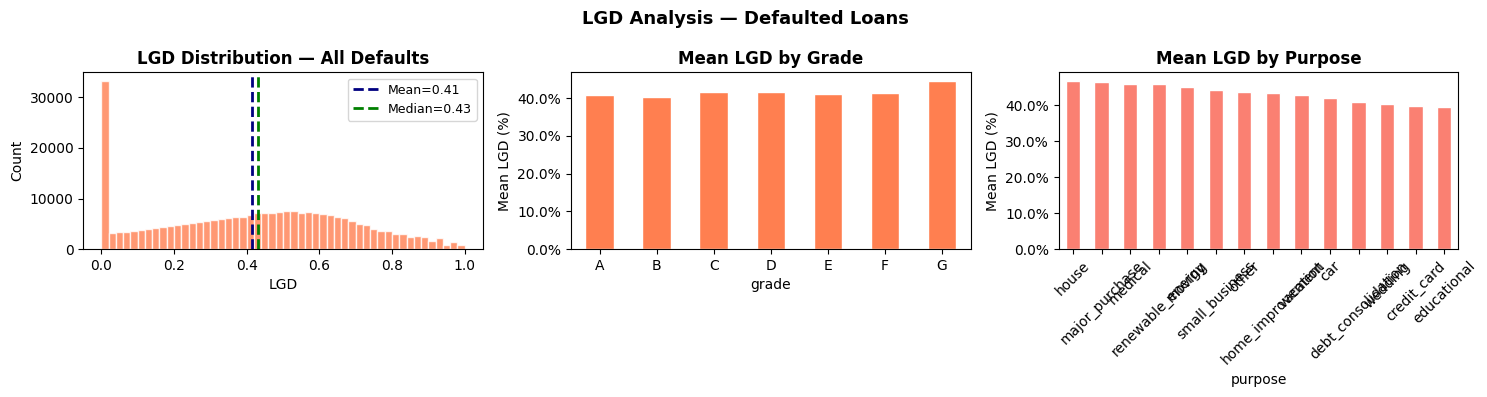

In [68]:
# 5. LGD DISTRIBUTION
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# overall LGD distribution
axes[0].hist(defaults['lgd'], bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[0].set_title('LGD Distribution — All Defaults', fontweight='bold')
axes[0].set_xlabel('LGD')
axes[0].set_ylabel('Count')
axes[0].axvline(defaults['lgd'].mean(),   color='navy',  linestyle='--',
                linewidth=2, label=f"Mean={defaults['lgd'].mean():.2f}")
axes[0].axvline(defaults['lgd'].median(), color='green', linestyle='--',
                linewidth=2, label=f"Median={defaults['lgd'].median():.2f}")
axes[0].legend(fontsize=9)

# LGD by grade
lgd_grade = defaults.groupby('grade')['lgd'].mean() * 100
lgd_grade.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Mean LGD by Grade', fontweight='bold')
axes[1].set_ylabel('Mean LGD (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=0)

# LGD by purpose
lgd_purpose = defaults.groupby('purpose')['lgd'].mean().sort_values(ascending=False) * 100
lgd_purpose.plot(kind='bar', ax=axes[2], color='salmon', edgecolor='white')
axes[2].set_title('Mean LGD by Purpose', fontweight='bold')
axes[2].set_ylabel('Mean LGD (%)')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('LGD Analysis — Defaulted Loans', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [69]:
# 6. TWO-STAGE LGD MODEL
# Stage 1: logistic — P(complete loss) i.e. LGD = 1 (zero recovery)
# Stage 2: linear on partial losses where 0 < LGD < 1

# features for LGD model — simpler set, only what's available at default
lgd_features_raw = ['funded_amnt', 'term', 'int_rate', 'annual_inc',
                     'dti', 'grade', 'purpose']

# keep only what exists
lgd_features_raw = [c for c in lgd_features_raw if c in defaults.columns]
print("LGD features:", lgd_features_raw)

# encode categoricals simply — label encode (LGD model doesn't need WoE)
lgd_data = defaults[lgd_features_raw + ['lgd', 'vintage']].copy()

# encode grade
grade_map = {'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7}
lgd_data['grade_n'] = lgd_data['grade'].map(grade_map).fillna(4)

# encode purpose — mean LGD per purpose (target encoding, safe here
# because we're not using it in PD model)
purpose_lgd = defaults.groupby('purpose')['lgd'].mean()
lgd_data['purpose_lgd_enc'] = lgd_data['purpose'].map(purpose_lgd).fillna(
    lgd_data['lgd'].mean())

# int_rate string fix if needed
if lgd_data['int_rate'].dtype == object:
    lgd_data['int_rate'] = lgd_data['int_rate'].str.replace('%','').astype(float)

lgd_num_features = ['funded_amnt', 'int_rate', 'annual_inc',
                     'dti', 'grade_n', 'purpose_lgd_enc']

# train/OOT split on defaulted loans
lgd_train = lgd_data[lgd_data['vintage'] <= 2011]
lgd_oot   = lgd_data[lgd_data['vintage'] >= 2012]

print(f"\nLGD train defaults: {len(lgd_train):,}")
print(f"LGD OOT  defaults : {len(lgd_oot):,}")

LGD features: ['funded_amnt', 'term', 'int_rate', 'annual_inc', 'dti', 'grade', 'purpose']

LGD train defaults: 5,670
LGD OOT  defaults : 262,929


In [70]:
# STAGE 1 — classify complete loss (LGD == 1 means zero recovery)
lgd_train['complete_loss'] = (lgd_train['lgd'] >= 0.99).astype(int)
lgd_oot['complete_loss']   = (lgd_oot['lgd']   >= 0.99).astype(int)

print(f"Complete loss rate (train): {lgd_train['complete_loss'].mean()*100:.1f}%")
print(f"Complete loss rate (OOT)  : {lgd_oot['complete_loss'].mean()*100:.1f}%")

X_lgd_tr = lgd_train[lgd_num_features].fillna(0)
X_lgd_oo = lgd_oot[lgd_num_features].fillna(0)

stage1 = LogisticRegression(C=1.0, solver='liblinear', random_state=42)
stage1.fit(X_lgd_tr, lgd_train['complete_loss'])

# P(complete loss)
lgd_train['p_complete_loss'] = stage1.predict_proba(X_lgd_tr)[:, 1]
lgd_oot['p_complete_loss']   = stage1.predict_proba(X_lgd_oo)[:, 1]

auc_s1 = roc_auc_score(lgd_oot['complete_loss'], lgd_oot['p_complete_loss'])
print(f"\nStage 1 AUROC (OOT): {auc_s1:.4f}")

Complete loss rate (train): 0.3%
Complete loss rate (OOT)  : 0.3%

Stage 1 AUROC (OOT): 0.4600


In [71]:
# STAGE 2 — predict LGD magnitude for partial losses
partial_train = lgd_train[lgd_train['complete_loss'] == 0].copy()
partial_oot   = lgd_oot[lgd_oot['complete_loss']   == 0].copy()

print(f"Partial loss loans — train: {len(partial_train):,}  OOT: {len(partial_oot):,}")

# log-transform LGD for better linear regression fit
# clip to avoid log(0)
partial_train['lgd_clipped'] = partial_train['lgd'].clip(0.001, 0.999)
partial_oot['lgd_clipped']   = partial_oot['lgd'].clip(0.001, 0.999)

stage2 = LinearRegression()
stage2.fit(partial_train[lgd_num_features].fillna(0),
           partial_train['lgd_clipped'])

partial_train['lgd_hat'] = stage2.predict(
    partial_train[lgd_num_features].fillna(0)).clip(0, 1)
partial_oot['lgd_hat']   = stage2.predict(
    partial_oot[lgd_num_features].fillna(0)).clip(0, 1)

r2  = r2_score(partial_oot['lgd_clipped'], partial_oot['lgd_hat'])
mse = mean_squared_error(partial_oot['lgd_clipped'], partial_oot['lgd_hat'])
print(f"\nStage 2 R² (OOT) : {r2:.4f}")
print(f"Stage 2 RMSE (OOT): {np.sqrt(mse):.4f}")

Partial loss loans — train: 5,653  OOT: 262,079

Stage 2 R² (OOT) : -0.0154
Stage 2 RMSE (OOT): 0.2645


In [72]:
# COMBINE STAGES — final LGD prediction
# E[LGD] = P(complete loss) × 1 + P(partial loss) × E[LGD | partial]

def predict_lgd(X, p_complete, stage2_model, lgd_features):
    lgd_partial = stage2_model.predict(X[lgd_features].fillna(0)).clip(0, 1)
    lgd_final   = p_complete * 1.0 + (1 - p_complete) * lgd_partial
    return lgd_final

lgd_train['lgd_pred'] = predict_lgd(lgd_train, lgd_train['p_complete_loss'],
                                     stage2, lgd_num_features)
lgd_oot['lgd_pred']   = predict_lgd(lgd_oot,   lgd_oot['p_complete_loss'],
                                     stage2, lgd_num_features)

print("Combined LGD predictions:")
for name, ds in [('Train', lgd_train), ('OOT', lgd_oot)]:
    print(f"  {name}: predicted LGD={ds['lgd_pred'].mean()*100:.1f}%  "
          f"actual LGD={ds['lgd'].mean()*100:.1f}%")

Combined LGD predictions:
  Train: predicted LGD=40.6%  actual LGD=40.5%
  OOT: predicted LGD=39.2%  actual LGD=41.4%


In [73]:
# 7. DOWNTURN LGD
# Basel requires LGD estimate to reflect stress conditions
# identify worst year in data and compute add-on

lgd_by_year = defaults.groupby('vintage')['lgd'].agg(['mean','count'])
lgd_by_year.columns = ['mean_lgd', 'count']

print("LGD by vintage year:")
print(lgd_by_year.round(4))

avg_lgd      = defaults['lgd'].mean()
downturn_lgd = lgd_by_year['mean_lgd'].max()
downturn_yr  = lgd_by_year['mean_lgd'].idxmax()

downturn_addon = max(0, downturn_lgd - avg_lgd)

print(f"\nAverage LGD       : {avg_lgd*100:.2f}%")
print(f"Downturn LGD      : {downturn_lgd*100:.2f}%  (year {downturn_yr})")
print(f"Downturn add-on   : {downturn_addon*100:.2f}%")

LGD by vintage year:
         mean_lgd  count
vintage                 
2007       0.3379     45
2008       0.4400    247
2009       0.4454    594
2010       0.4007   1487
2011       0.3979   3297
2012       0.3489   8644
2013       0.3000  21024
2014       0.3097  41162
2015       0.3632  75804
2016       0.4261  68252
2017       0.5841  39169
2018       0.8119   8874

Average LGD       : 41.35%
Downturn LGD      : 81.19%  (year 2018)
Downturn add-on   : 39.85%



LGD after downturn adjustment and 30% floor:
  Mean: 79.08%
  Min : 39.85%
  Max : 100.00%


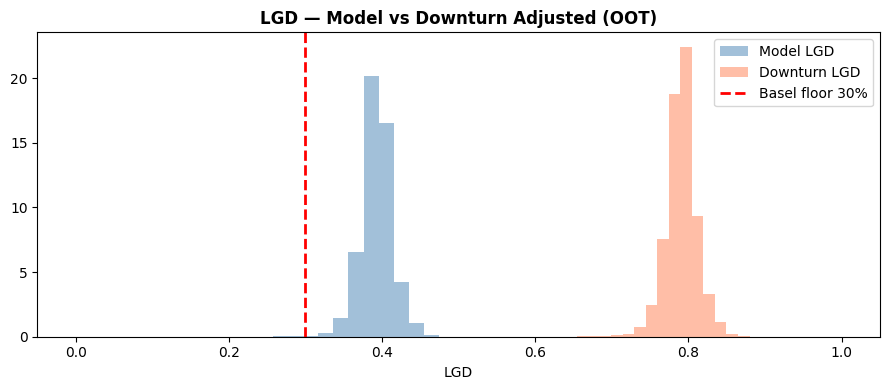

In [74]:
# apply downturn add-on and Basel floor
BASEL_LGD_FLOOR = 0.30   # 30% floor for unsecured retail

lgd_oot['lgd_downturn'] = (lgd_oot['lgd_pred'] + downturn_addon).clip(
    lower=BASEL_LGD_FLOOR, upper=1.0)

print(f"\nLGD after downturn adjustment and {BASEL_LGD_FLOOR*100:.0f}% floor:")
print(f"  Mean: {lgd_oot['lgd_downturn'].mean()*100:.2f}%")
print(f"  Min : {lgd_oot['lgd_downturn'].min()*100:.2f}%")
print(f"  Max : {lgd_oot['lgd_downturn'].max()*100:.2f}%")

# LGD plot — raw vs calibrated vs downturn
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lgd_oot['lgd_pred'],     bins=40, alpha=0.5, color='steelblue',
        label='Model LGD',      density=True)
ax.hist(lgd_oot['lgd_downturn'], bins=40, alpha=0.5, color='coral',
        label='Downturn LGD',   density=True)
ax.axvline(BASEL_LGD_FLOOR, color='red', linestyle='--',
           linewidth=2, label=f'Basel floor {BASEL_LGD_FLOOR*100:.0f}%')
ax.set_title('LGD — Model vs Downturn Adjusted (OOT)', fontweight='bold')
ax.set_xlabel('LGD')
ax.legend()
plt.tight_layout()
plt.show()

EAD validation on defaulted loans:
       funded_amnt         ead
count  268599.0000 268599.0000
mean    15556.8800  15556.1700
std      8811.2200   8811.1900
min       900.0000    468.0100
25%      9000.0000   9000.0000
50%     14325.0000  14325.0000
75%     20400.0000  20400.0000
max     40000.0000  40000.0000


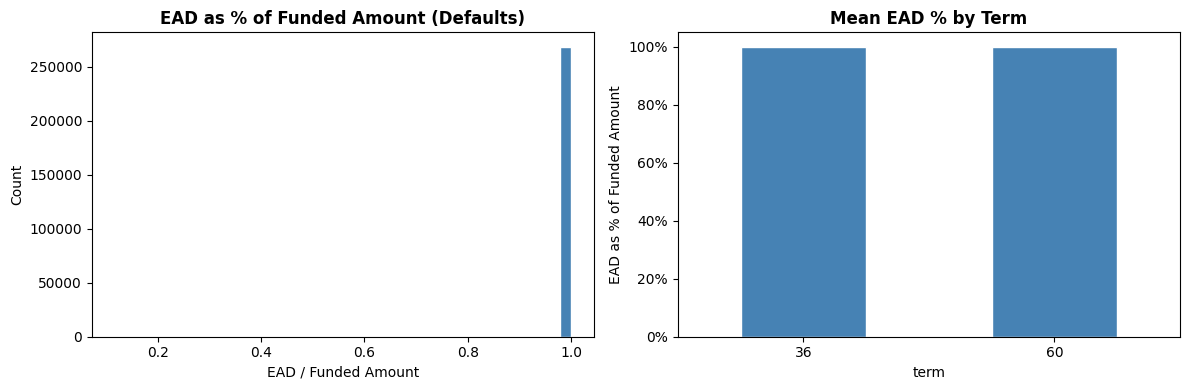


Mean EAD % of funded amount: 100.0%
(60-month loans default later → lower EAD % because more principal repaid)


In [75]:
# 8. EAD ANALYSIS
# for term loans EAD = outstanding balance — no CCF needed
# we already computed it; just validate it makes sense

print("EAD validation on defaulted loans:")
print(defaults[['funded_amnt','ead']].describe().round(2))

# EAD as % of funded amount
defaults['ead_pct'] = defaults['ead'] / defaults['funded_amnt']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(defaults['ead_pct'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('EAD as % of Funded Amount (Defaults)', fontweight='bold')
axes[0].set_xlabel('EAD / Funded Amount')
axes[0].set_ylabel('Count')

# EAD by term
defaults.groupby('term')['ead_pct'].mean().mul(100).plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Mean EAD % by Term', fontweight='bold')
axes[1].set_ylabel('EAD as % of Funded Amount')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f"\nMean EAD % of funded amount: {defaults['ead_pct'].mean()*100:.1f}%")
print("(60-month loans default later → lower EAD % because more principal repaid)")

In [76]:
# 9. BRING PD + LGD + EAD TOGETHER
# merge LGD predictions back onto the full OOT dataset

# we have lgd_oot with index from defaults — merge on index
lgd_oot_merge = lgd_oot[['lgd_pred', 'lgd_downturn']].copy()

# full OOT
oot_full = oot_pd.copy()
oot_full['ead'] = all_data.loc[all_data['vintage'] >= 2017, 'ead'].values \
    if 'vintage' in all_data.columns else oot_pd['funded_amnt']

# for non-defaulted loans we still need LGD for EXPECTED loss computation
# use the average predicted LGD from the model as the best estimate
mean_lgd_model    = lgd_oot['lgd_pred'].mean()
mean_lgd_downturn = lgd_oot['lgd_downturn'].mean()

print(f"Mean model LGD    : {mean_lgd_model*100:.2f}%")
print(f"Mean downturn LGD : {mean_lgd_downturn*100:.2f}%")
print("\nApplying mean LGD to all OOT loans (defaulted and non-defaulted)")
print("In practice: score each loan through the LGD model individually")

Mean model LGD    : 39.24%
Mean downturn LGD : 79.08%

Applying mean LGD to all OOT loans (defaulted and non-defaulted)
In practice: score each loan through the LGD model individually


In [77]:
#10. COMPUTE EL = PD × LGD × EAD

oot_el = oot_pd.copy()

# PD — calibrated with MoC and floor (from part 4)
oot_el['pd_final'] = oot_pd['pd_cal'].clip(lower=0.0003)

# LGD — use downturn adjusted mean for all active loans
# (in production: score each loan through LGD model individually)
oot_el['lgd_final'] = mean_lgd_downturn

# EAD
if 'ead' in all_data.columns:
    oot_el['ead'] = all_data.loc[
        all_data['vintage'].isin(oot_pd['vintage'].unique()), 'ead'
    ].values[:len(oot_el)]
else:
    oot_el['ead'] = oot_el['funded_amnt']

# EXPECTED LOSS
oot_el['el_dollar'] = oot_el['pd_final'] * oot_el['lgd_final'] * oot_el['ead']
oot_el['el_rate']   = oot_el['pd_final'] * oot_el['lgd_final']  # as % of EAD

print("Expected Loss computed ✓")
print(f"\nPortfolio summary (OOT loans):")
print(f"  Number of loans      : {len(oot_el):,}")
print(f"  Total EAD            : ${oot_el['ead'].sum():,.0f}")
print(f"  Total Expected Loss  : ${oot_el['el_dollar'].sum():,.0f}")
print(f"  Portfolio EL rate    : {oot_el['el_dollar'].sum()/oot_el['ead'].sum()*100:.2f}%")
print(f"  Mean PD              : {oot_el['pd_final'].mean()*100:.2f}%")
print(f"  LGD (downturn)       : {mean_lgd_downturn*100:.2f}%")

Expected Loss computed ✓

Portfolio summary (OOT loans):
  Number of loans      : 225,639
  Total EAD            : $3,259,473,894
  Total Expected Loss  : $500,236,592
  Portfolio EL rate    : 15.35%
  Mean PD              : 17.84%
  LGD (downturn)       : 79.08%


In [78]:
# 11. EL BREAKDOWN BY GRADE

el_by_grade = oot_el.groupby('grade').agg(
    loans      = ('el_dollar',   'count'),
    total_ead  = ('ead',         'sum'),
    mean_pd    = ('pd_final',    'mean'),
    mean_lgd   = ('lgd_final',   'mean'),
    total_el   = ('el_dollar',   'sum'),
).reset_index()

el_by_grade['el_rate']   = el_by_grade['total_el'] / el_by_grade['total_ead'] * 100
el_by_grade['ead_share'] = el_by_grade['total_ead'] / el_by_grade['total_ead'].sum() * 100
el_by_grade['el_share']  = el_by_grade['total_el'] / el_by_grade['total_el'].sum() * 100

print("EL Breakdown by Grade:")
print(el_by_grade[['grade','loans','total_ead','mean_pd',
                   'el_rate','total_el','ead_share','el_share']
      ].round(4).to_string(index=False))

EL Breakdown by Grade:
grade  loans       total_ead  mean_pd  el_rate       total_el  ead_share  el_share
    A  39710  524775652.3500   0.0586   4.6519  24411919.0035    16.1000    4.8801
    B  62234  831126902.5600   0.1136   9.3900  78042618.7979    25.4988   15.6011
    C  69674 1021409342.8300   0.2006  16.6788 170359271.0249    31.3366   34.0557
    D  34196  530727688.0300   0.2729  22.3877 118817848.6633    16.2826   23.7523
    E  13246  221519257.8600   0.3551  28.8655  63942681.4501     6.7962   12.7825
    F   4309   82582400.0000   0.4230  33.7336  27858026.6228     2.5336    5.5690
    G   2270   47332650.0000   0.4510  35.5024  16804226.7672     1.4522    3.3593


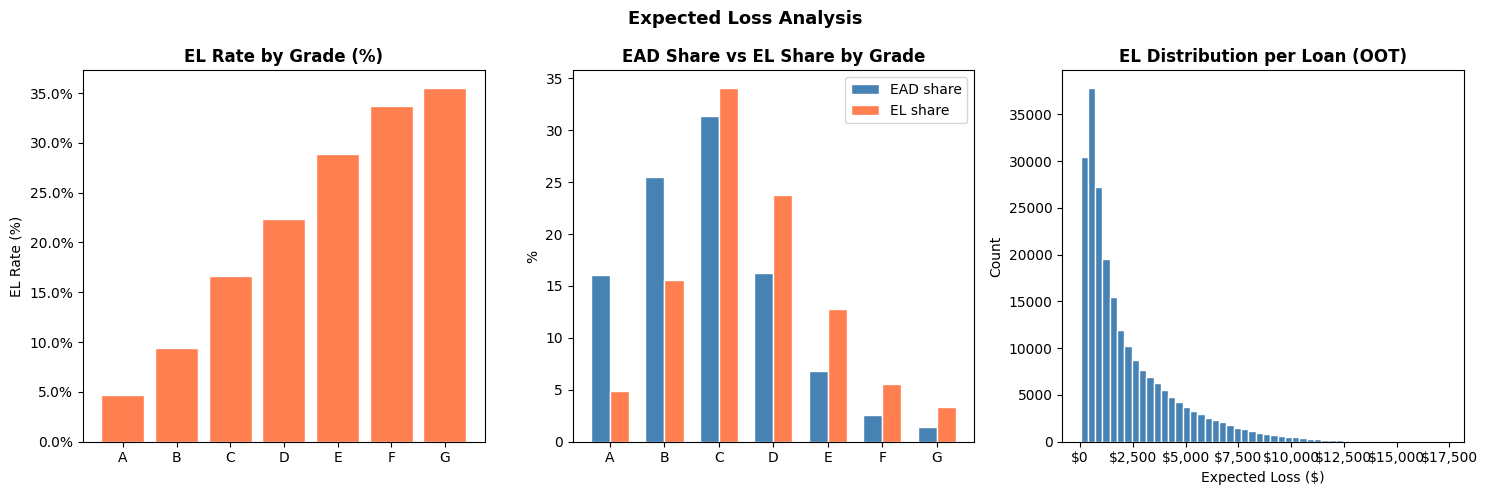

In [79]:
# EL visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# EL rate by grade
axes[0].bar(el_by_grade['grade'], el_by_grade['el_rate'],
            color='coral', edgecolor='white')
axes[0].set_title('EL Rate by Grade (%)', fontweight='bold')
axes[0].set_ylabel('EL Rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# EAD share vs EL share
x = np.arange(len(el_by_grade))
w = 0.35
axes[1].bar(x - w/2, el_by_grade['ead_share'], w,
            label='EAD share', color='steelblue', edgecolor='white')
axes[1].bar(x + w/2, el_by_grade['el_share'],  w,
            label='EL share',  color='coral',     edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(el_by_grade['grade'])
axes[1].set_title('EAD Share vs EL Share by Grade', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].legend()
# if EL share >> EAD share for a grade, that grade punches above its weight in risk

# EL distribution across loans
axes[2].hist(oot_el['el_dollar'], bins=50, color='steelblue', edgecolor='white')
axes[2].set_title('EL Distribution per Loan (OOT)', fontweight='bold')
axes[2].set_xlabel('Expected Loss ($)')
axes[2].set_ylabel('Count')
axes[2].xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Expected Loss Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## EXAMPLE

In [80]:
# 12. WORKED EXAMPLE — 5 INDIVIDUAL LOANS

sample = oot_el[['grade','funded_amnt','pd_final',
                  'lgd_final','ead','el_dollar','el_rate']
                ].sample(5, random_state=42).copy()

sample.columns = ['Grade','Funded ($)','PD','LGD','EAD ($)','EL ($)','EL Rate']
sample = sample.sort_values('Grade')

print("Sample Loan-Level EL:")
print("-" * 70)
for _, row in sample.iterrows():
    print(f"  Grade {row['Grade']}  |  "
          f"Funded=${row['Funded ($)']:>8,.0f}  |  "
          f"PD={row['PD']*100:>5.2f}%  |  "
          f"LGD={row['LGD']*100:>5.1f}%  |  "
          f"EAD=${row['EAD ($)']:>8,.0f}  |  "
          f"EL=${row['EL ($)']:>7,.0f}  ({row['EL Rate']*100:.2f}%)")
print("-" * 70)
print(f"  {'TOTAL':>6}  |  "
      f"Funded=${sample['Funded ($)'].sum():>8,.0f}  |  "
      f"{'':>11}  {'':>11}  "
      f"EAD=${sample['EAD ($)'].sum():>8,.0f}  |  "
      f"EL=${sample['EL ($)'].sum():>7,.0f}")

Sample Loan-Level EL:
----------------------------------------------------------------------
  Grade A  |  Funded=$  15,000  |  PD= 5.01%  |  LGD= 79.1%  |  EAD=$  15,000  |  EL=$    594  (3.96%)
  Grade B  |  Funded=$  25,000  |  PD=16.83%  |  LGD= 79.1%  |  EAD=$  25,000  |  EL=$  3,328  (13.31%)
  Grade C  |  Funded=$   6,400  |  PD=25.32%  |  LGD= 79.1%  |  EAD=$   6,400  |  EL=$  1,282  (20.02%)
  Grade D  |  Funded=$  17,000  |  PD=28.41%  |  LGD= 79.1%  |  EAD=$  17,000  |  EL=$  3,819  (22.47%)
  Grade E  |  Funded=$  14,400  |  PD=32.87%  |  LGD= 79.1%  |  EAD=$  14,400  |  EL=$  3,743  (25.99%)
----------------------------------------------------------------------
   TOTAL  |  Funded=$  77,800  |                            EAD=$  77,800  |  EL=$ 12,766


In [81]:
# 13. RWA — SIMPLIFIED BASEL IRBA FORMULA
# shows how EL feeds into regulatory capital

from scipy.stats import norm

def basel_rwa(pd, lgd, ead, R=0.15, M=2.5):
    """
    Basel IRBA capital formula for retail exposures.
    R = asset correlation (0.03-0.16 for retail)
    M = effective maturity
    """
    pd  = np.clip(pd, 0.0003, 0.9999)
    lgd = np.clip(lgd, 0.0001, 0.9999)

    # capital requirement K
    K = (lgd * norm.cdf(
            (norm.ppf(pd) + np.sqrt(R) * norm.ppf(0.999))
            / np.sqrt(1 - R)
         ) - pd * lgd)

    # maturity adjustment (simplified)
    b  = (0.11852 - 0.05478 * np.log(pd)) ** 2
    ma = (1 + (M - 2.5) * b) / (1 - 1.5 * b)
    K  = K * ma

    rwa     = K * 12.5 * ead
    capital = rwa * 0.08   # 8% minimum
    return K, rwa, capital

oot_el[['K','rwa','capital_req']] = oot_el.apply(
    lambda r: pd.Series(
        basel_rwa(r['pd_final'], r['lgd_final'], r['ead'])
    ), axis=1)

total_ead     = oot_el['ead'].sum()
total_el      = oot_el['el_dollar'].sum()
total_rwa     = oot_el['rwa'].sum()
total_capital = oot_el['capital_req'].sum()

print("Portfolio Capital Summary:")
print(f"  Total EAD             : ${total_ead:>15,.0f}")
print(f"  Total Expected Loss   : ${total_el:>15,.0f}  "
      f"({total_el/total_ead*100:.2f}% of EAD)")
print(f"  Total RWA             : ${total_rwa:>15,.0f}  "
      f"({total_rwa/total_ead*100:.1f}% of EAD)")
print(f"  Min Capital Required  : ${total_capital:>15,.0f}  "
      f"({total_capital/total_ead*100:.2f}% of EAD)")
print(f"\n  Capital / EL ratio    : {total_capital/total_el:.2f}x")
print("  (capital covers unexpected loss; EL is covered by pricing)")

Portfolio Capital Summary:
  Total EAD             : $  3,259,473,894
  Total Expected Loss   : $    500,236,592  (15.35% of EAD)
  Total RWA             : $ 13,955,567,680  (428.2% of EAD)
  Min Capital Required  : $  1,116,445,414  (34.25% of EAD)

  Capital / EL ratio    : 2.23x
  (capital covers unexpected loss; EL is covered by pricing)


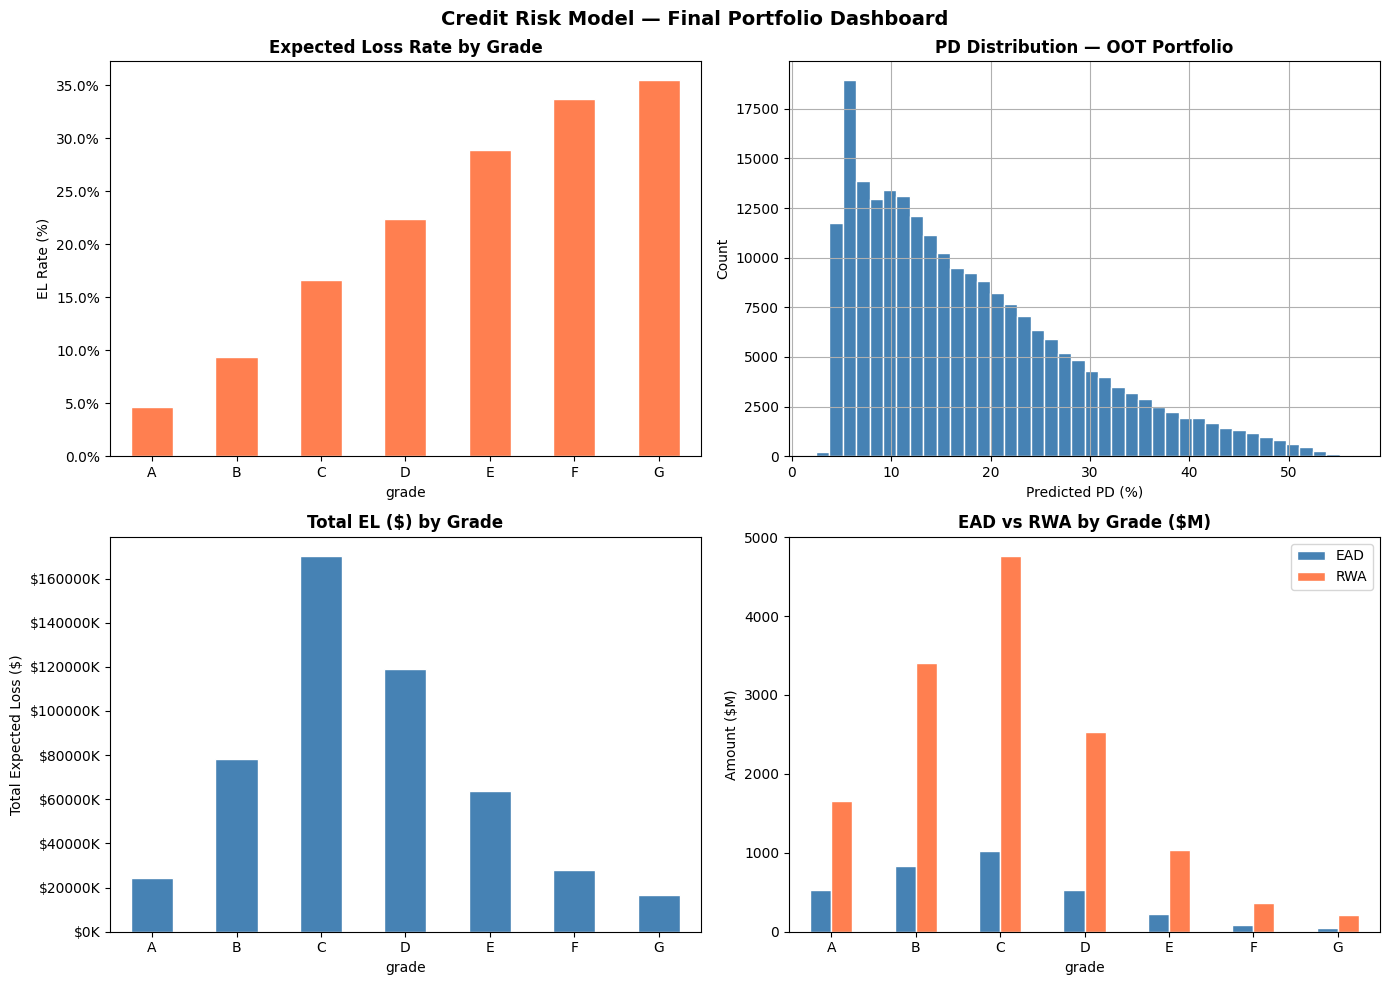

In [82]:
# 14. FINAL SUMMARY DASHBOARD

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. EL rate by grade
el_by_grade.plot(x='grade', y='el_rate', kind='bar',
                 ax=axes[0,0], color='coral', edgecolor='white', legend=False)
axes[0,0].set_title('Expected Loss Rate by Grade', fontweight='bold')
axes[0,0].set_ylabel('EL Rate (%)')
axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0,0].tick_params(axis='x', rotation=0)

# 2. PD distribution
oot_el['pd_final'].mul(100).hist(bins=40, ax=axes[0,1],
                                  color='steelblue', edgecolor='white')
axes[0,1].set_title('PD Distribution — OOT Portfolio', fontweight='bold')
axes[0,1].set_xlabel('Predicted PD (%)')
axes[0,1].set_ylabel('Count')

# 3. EL $ by grade — absolute risk contribution
el_by_grade.plot(x='grade', y='total_el', kind='bar',
                 ax=axes[1,0], color='steelblue', edgecolor='white', legend=False)
axes[1,0].set_title('Total EL ($) by Grade', fontweight='bold')
axes[1,0].set_ylabel('Total Expected Loss ($)')
axes[1,0].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1,0].tick_params(axis='x', rotation=0)

# 4. RWA vs EAD by grade
rwa_grade = oot_el.groupby('grade')[['ead','rwa']].sum() / 1e6
rwa_grade.plot(kind='bar', ax=axes[1,1],
               color=['steelblue','coral'], edgecolor='white')
axes[1,1].set_title('EAD vs RWA by Grade ($M)', fontweight='bold')
axes[1,1].set_ylabel('Amount ($M)')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend(['EAD','RWA'])

plt.suptitle('Credit Risk Model — Final Portfolio Dashboard',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [84]:
# 15. SAVE EVERYTHING

oot_el.to_parquet('oot_el_final.parquet', index=False)

# save LGD models
with open('lgd_stage1.pkl', 'wb') as f:
    pickle.dump(stage1, f)
with open('lgd_stage2.pkl', 'wb') as f:
    pickle.dump(stage2, f)

# final model summary
summary = {
    'n_loans'          : len(oot_el),
    'total_ead'        : total_ead,
    'total_el'         : total_el,
    'el_rate_pct'      : total_el / total_ead * 100,
    'mean_pd_pct'      : oot_el['pd_final'].mean() * 100,
    'lgd_downturn_pct' : mean_lgd_downturn * 100,
    'total_rwa'        : total_rwa,
    'capital_required' : total_capital,
    'gini_oot'         : gini_oo,
    'ks_oot'           : ks_oo,}

print("\n" + "="*50)
print("FINAL MODEL SUMMARY")
print("="*50)
for k, v in summary.items():
    print(f"  {k:<25}: {v:,.4f}" if isinstance(v, float) else
          f"  {k:<25}: {v:,}")

print("\nProject complete: ok")
print("\nFiles saved:")
print("  oot_el_final.parquet — loan-level PD, LGD, EAD, EL, RWA")
print("  lgd_stage1.pkl       — LGD stage 1 logistic model")
print("  lgd_stage2.pkl       — LGD stage 2 linear model")


FINAL MODEL SUMMARY
  n_loans                  : 225,639
  total_ead                : 3,259,473,893.6300
  total_el                 : 500,236,592.3296
  el_rate_pct              : 15.3472
  mean_pd_pct              : 17.8394
  lgd_downturn_pct         : 79.0848
  total_rwa                : 13,955,567,680.4294
  capital_required         : 1,116,445,414.4344
  gini_oot                 : 0.3836
  ks_oot                   : 0.2798

Project complete: ok

Files saved:
  oot_el_final.parquet — loan-level PD, LGD, EAD, EL, RWA
  lgd_stage1.pkl       — LGD stage 1 logistic model
  lgd_stage2.pkl       — LGD stage 2 linear model
